# Asistente para consultar los reglamentos estudiantiles de Icesi

Taller de NLP. Lo hicimos a partir de los notebooks de la sesión de herramientas, agentes y MCP con Ollama (1-herramientas-y-agentes-con-ollama, 2-mcp-langchain-ollama y 3-chatbot-con-mcp-y-gradio) y de la clase de Retrieval Augmented Generation.

Grupo: Julián Espinosa, Jhon Jairo Cuervo y David Crespo.

## El problema

Como estudiantes, muchas veces tenemos dudas sobre las reglas de la universidad: cuántas fallas se pueden tener, hasta cuándo se puede cancelar una materia, qué pasa si baja el promedio o cómo se reclama una nota. Todo eso está en los reglamentos, pero son documentos de más de 30 páginas y casi nadie los lee completos.

Preguntarle directamente a un modelo de lenguaje no sirve mucho. El modelo no conoce los reglamentos de Icesi, que además cambiaron en marzo de 2026, y cuando no sabe algo puede inventar una respuesta. En este tema una respuesta inventada puede hacer que alguien pierda una materia o un plazo.

Por eso hicimos un asistente con RAG. Antes de responder, el sistema busca los artículos relacionados con la pregunta y el modelo responde solo con esa información, diciendo de qué reglamento y de qué artículo la sacó. Así cualquiera puede ir al documento y revisar.

Trabajamos con dos documentos: el reglamento de pregrado y el de posgrado. Los dos hablan de los mismos temas, pero con reglas distintas. Por ejemplo, en pregrado se pierde una materia con menos del 80 % de asistencia y en posgrado con menos del 70 %. Si el buscador trae el artículo del reglamento que no es, la respuesta sale mal aunque el modelo no se invente nada.

## Qué cambiamos respecto a los notebooks de la sesión

- En la sesión, el agente tenía una calculadora y una consulta del clima. Aquí la herramienta es un buscador sobre los reglamentos, y lo montamos como servidor MCP igual que en la guía.
- Armamos el RAG completo: descarga de los PDF, separación por artículos, pedazos de texto, embeddings y búsqueda.
- Probamos dos formas de partir el texto y dos modelos de embeddings.
- Probamos cuatro formas de buscar: con embeddings, por palabras (BM25), una mezcla de las dos y la mezcla con un re-ranker.
- Hicimos un grupo de preguntas con su artículo correcto para medir la búsqueda, y otras que no están en los reglamentos para ver si el modelo dice que no sabe.
- Comparamos dos modelos de lenguaje en Ollama.
- El chatbot de Gradio deja escoger el reglamento y muestra de qué artículos salió cada respuesta.

## 0. Preparación del entorno

In [1]:
import warnings
warnings.filterwarnings('ignore')

try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

print(f"Corriendo en Colab: {IN_COLAB}")

Corriendo en Colab: True


In [2]:
!pip install -q pypdf sentence-transformers gradio ollama httpx langchain langchain-core langchain-ollama langgraph "mcp>=1.24.0,<2.0.0" "langchain-mcp-adapters>=0.3.0,<0.4.0"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 401.7/401.7 kB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 234.6/234.6 kB 12.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.4/69.4 kB 3.9 MB/s eta 0:00:00


In [3]:
import os
import re
import sys
import json
import time
import math
import random
import socket
import subprocess
import unicodedata
from bisect import bisect_right
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
CON_GPU = DEVICE == 'cuda'
print(f"Dispositivo: {DEVICE}")

plt.rcParams.update({'axes.spines.top': False, 'axes.spines.right': False, 'axes.grid': True,
                     'grid.alpha': 0.3, 'figure.dpi': 100})
COLOR_DOC = {'pregrado': '#2a78d6', 'posgrado': '#eb6834'}

Dispositivo: cuda


Igual que en los talleres anteriores, el notebook cambia según el hardware. La búsqueda corre bien en CPU, pero generar respuestas con un modelo de 3 mil millones de parámetros es lento sin GPU. Con GPU se comparan dos modelos y se usan todas las preguntas. Sin GPU se usa un solo modelo y 10 preguntas.

Nosotros lo corrimos en Colab con una GPU T4, así que los resultados son los de la versión completa.

In [4]:
CONFIG = {
    'modelos_llm': ['llama3.2:3b', 'qwen2.5:3b'] if CON_GPU else ['llama3.2:3b'],
    'preguntas_generacion': None if CON_GPU else 10,   # None = todas
    'max_tokens_respuesta': 300 if CON_GPU else 200,
    'k_fragmentos': 4,                                  # fragmentos que recibe el modelo
    'n_candidatos': 20,                                 # candidatos que revisa el re-ranker
    'chunk_chars': 900,                                 # fragmentación de tamaño fijo
    'chunk_solape': 150,
    'max_palabras_articulo': 220,                       # fragmentación por artículo
    'solape_palabras': 50,
    'reranker': 'cross-encoder/mmarco-mMiniLMv2-L12-H384-v1',
    'puerto_mcp': 9090,
}
for k, v in CONFIG.items():
    print(f"{k:>22}: {v}")

           modelos_llm: ['llama3.2:3b', 'qwen2.5:3b']
  preguntas_generacion: None
  max_tokens_respuesta: 300
          k_fragmentos: 4
          n_candidatos: 20
           chunk_chars: 900
          chunk_solape: 150
 max_palabras_articulo: 220
       solape_palabras: 50
              reranker: cross-encoder/mmarco-mMiniLMv2-L12-H384-v1
            puerto_mcp: 9090


## 1. Los documentos

Usamos los dos reglamentos vigentes, que están en la página de normatividad académica de la universidad:

- Pregrado: Resolución de Rectoría 1690 de 2026, del 24 de marzo de 2026, con el texto completo del Libro de Derechos, Deberes y Normas de los Estudiantes de Pregrado.
- Posgrado: Resolución de Rectoría 1691 de 2026, de la misma fecha, con el texto completo del reglamento de posgrado.

Si la descarga falla, se pueden subir los PDF a mano a la carpeta docs, con los nombres que aparecen en el código.

In [14]:
!mv docs/Reso-1690*.pdf docs/reglamento_pregrado.pdf
!mv docs/Reso-1691*.pdf docs/reglamento_posgrado.pdf
!ls -la docs

mv: cannot stat 'docs/Reso-1690*.pdf': No such file or directory
mv: cannot stat 'docs/Reso-1691*.pdf': No such file or directory
total 928
drwxr-xr-x 2 root root   4096 Oct 11 00:10 .
drwxr-xr-x 1 root root   4096 Oct 11 00:02 ..
-rw-r--r-- 1 root root 486921 Oct 11 00:09 reglamento_posgrado.pdf
-rw-r--r-- 1 root root 454289 Oct 11 00:09 reglamento_pregrado.pdf


In [15]:
from pypdf import PdfReader

paginas = {}
for clave, info in DOCUMENTOS.items():
    lector = PdfReader(str(info['archivo']))
    paginas[clave] = [p.extract_text() or '' for p in lector.pages]
    total = sum(len(p) for p in paginas[clave])
    print(f"{info['nombre']}: {len(paginas[clave])} páginas, {total:,} caracteres")

print('\nInicio de la página 3 del reglamento de pregrado:\n')
print(paginas['pregrado'][2][:800])

Reglamento de pregrado: 37 páginas, 88,919 caracteres
Reglamento de posgrado: 35 páginas, 84,453 caracteres

Inicio de la página 3 del reglamento de pregrado:

 
 
Resolución de Rectoría No. 1.690/2026 
Página 3 de 37 
 
Comité de Admisiones; como instancias consultivas el Comité de Rectoría, el Consejo de 
Facultad, el Comité de Currículo y el Comité Ético. 
 
CAPÍTULO II. PROGRAMAS ACADÉMICOS DE PREGRADO 
 
ARTÍCULO 2. La Universidad Icesi ofrecerá programas académicos de pregrado, de acuerdo 
con las autorizaciones del Consejo Superior, previa autorización de registro ante el 
Ministerio de Educación Nacional. 
 
ARTÍCULO 3. Los programas de pregrado serán conducentes a títulos profesionales. 
 
CAPÍTULO III. DERECHOS Y DEBERES DE LOS ESTUDIANTES 
 
ARTÍCULO 4. Se considera estudiante de pregrado de la Universidad toda persona que se 
encuentre con matrícula vigente en uno de los programas regulares de este nivel que ofrece 
la Institución. 
 


In [16]:
import requests

DOCUMENTOS = {
    'pregrado': {
        'nombre': 'Reglamento de pregrado',
        'url': 'https://www.icesi.edu.co/wp-content/uploads/2024/08/Reso-1690-Modifica-LDDN-reglamento-pregrado.pdf',
        'archivo': Path('docs/reglamento_pregrado.pdf'),
    },
    'posgrado': {
        'nombre': 'Reglamento de posgrado',
        'url': 'https://www.icesi.edu.co/wp-content/uploads/2026/04/Reso-1691-Modifica-reglamento-de-posgrado.pdf',
        'archivo': Path('docs/reglamento_posgrado.pdf'),
    },
}

Path('docs').mkdir(exist_ok=True)
for clave, info in DOCUMENTOS.items():
    if info['archivo'].exists():
        print(f"{info['nombre']}: ya existe")
        continue
    r = requests.get(info['url'], headers={'User-Agent': 'Mozilla/5.0'}, timeout=60)
    if r.status_code == 200 and r.content[:4] == b'%PDF':
        info['archivo'].write_bytes(r.content)
        print(f"{info['nombre']}: descargado ({len(r.content) / 1024:.0f} KB)")
    else:
        print(f"{info['nombre']}: no se pudo descargar (código {r.status_code}). Súbalo a mano como {info['archivo']}")

Reglamento de pregrado: ya existe
Reglamento de posgrado: ya existe


### Separación por artículos

Como queremos que las respuestas digan el artículo, separamos el texto por artículos. Buscamos las líneas que empiezan con "Artículo" y un número, y solo aceptamos las que siguen el orden (el 12 después del 11). Así no confundimos el comienzo de un artículo con una frase como "según el artículo 54". También guardamos el capítulo y la página de cada artículo, y quitamos los encabezados que se repiten en cada hoja, como "Página 3 de 37".

In [17]:
PAT_ARTICULO = re.compile(r'(?im)^[ \t]*art[íi]culo[ \t]+(\d{1,3})\b[ \t]*[°º\.\-:]?')
PAT_CAPITULO = re.compile(r'(?im)^[ \t]*cap[íi]tulo[ \t]+([IVXLC]+)\b[ \t\.\-:]*(.*)$')
PAT_RUIDO = [
    re.compile(r'(?i)^\s*p[áa]gina\s+\d+\s+de\s+\d+.*$'),
    re.compile(r'(?i)^\s*resoluci[óo]n de rector[íi]a.{0,40}$'),
    re.compile(r'(?i)^\s*universidad icesi\s*$'),
    re.compile(r'^\s*\d{1,3}\s*$'),
]


def limpiar_pagina(texto):
    lineas = [l for l in texto.split('\n') if not any(p.match(l) for p in PAT_RUIDO)]
    return '\n'.join(lineas)


def separar_articulos(clave):
    texto, inicios_pagina = '', []
    for pag in paginas[clave]:
        inicios_pagina.append(len(texto))
        texto += limpiar_pagina(pag) + '\n'

    # Encabezados de artículo que siguen la numeración
    aceptados, ultimo = [], 0
    for m in PAT_ARTICULO.finditer(texto):
        n = int(m.group(1))
        if n == 1 and ultimo <= 3:
            aceptados, ultimo = [(n, m.start())], 1      # el texto del reglamento empieza (o reinicia) en el artículo 1
        elif n in (ultimo + 1, ultimo + 2):
            aceptados.append((n, m.start()))
            ultimo = n

    capitulos = [(m.start(), f"Capítulo {m.group(1)}", m.group(2).strip()) for m in PAT_CAPITULO.finditer(texto)]

    filas = []
    for i, (n, inicio) in enumerate(aceptados):
        fin = aceptados[i + 1][1] if i + 1 < len(aceptados) else len(texto)
        previos = [c for c in capitulos if c[0] < inicio]
        capitulo = previos[-1][1] if previos else 'Sin capítulo'
        cuerpo = re.sub(r'[ \t]+', ' ', texto[inicio:fin]).strip()
        filas.append({'doc': clave, 'articulo': n, 'capitulo': capitulo,
                      'pagina': bisect_right(inicios_pagina, inicio), 'inicio': inicio, 'fin': fin,
                      'texto': cuerpo, 'palabras': len(cuerpo.split())})
    return pd.DataFrame(filas), texto


articulos, textos_completos = [], {}
for clave in DOCUMENTOS:
    df_doc, textos_completos[clave] = separar_articulos(clave)
    articulos.append(df_doc)
    numeros = df_doc['articulo'].tolist()
    faltantes = sorted(set(range(1, max(numeros) + 1)) - set(numeros))
    print(f"{DOCUMENTOS[clave]['nombre']}: {len(df_doc)} artículos (del 1 al {max(numeros)}); "
          f"números no encontrados: {faltantes if faltantes else 'ninguno'}")
df_art = pd.concat(articulos, ignore_index=True)
df_art.head()

Reglamento de pregrado: 110 artículos (del 1 al 110); números no encontrados: ninguno
Reglamento de posgrado: 91 artículos (del 1 al 91); números no encontrados: ninguno


,doc,articulo,capitulo,pagina,inicio,fin,texto,palabras
0,pregrado,1,Capítulo l,2,2876,3419,ARTÍCULO 1. La Universidad tiene como órganos ...,68
1,pregrado,2,Capítulo II,3,3419,3630,ARTÍCULO 2. La Universidad Icesi ofrecerá prog...,28
2,pregrado,3,Capítulo II,3,3630,3769,ARTÍCULO 3. Los programas de pregrado serán co...,19
3,pregrado,4,Capítulo III,3,3769,3967,ARTÍCULO 4. Se considera estudiante de pregrad...,31
4,pregrado,5,Capítulo III,3,3967,5601,ARTÍCULO 5. Son derechos de los estudiantes: \...,245


In [18]:
# Revisión manual: inicio de algunos artículos que usaremos en la evaluación
for clave, n in [('pregrado', 70), ('pregrado', 54), ('posgrado', 44), ('posgrado', 41)]:
    fila = df_art[(df_art['doc'] == clave) & (df_art['articulo'] == n)]
    if len(fila):
        f = fila.iloc[0]
        print(f"[{clave} | artículo {n} | {f['capitulo']} | página {f['pagina']}]\n{f['texto'][:350]}\n")

[pregrado | artículo 70 | Capítulo XVI | página 22]
ARTÍCULO 70. Las calificaciones numéricas que se aplican en cada evaluación, como en la 
nota definitiva de cada materia, y en el cálculo del promedio acumulado y del promedio del 
semestre están en la escala cero (0,0) a cinco (5,0), entendiéndose que una calificación 
inferior a tres cero (3,0) indica reprobación y una calificación igual o superi

[pregrado | artículo 54 | Capítulo X | página 17]
ARTÍCULO 54. Una materia podrá ser cancelada sólo dos veces. 
Para este efecto deben considerarse: 
• Las materias equivalentes. 
• En caso de traslado de un programa a otro en la Universidad. 
• Cuentan todas las cancelaciones con pago o excepcionales.

[posgrado | artículo 44 | Capítulo X | página 17]
ARTÍCULO 44. Las calificaciones se aplicarán en la Universidad Icesi para cada evaluación, 
examen o prueba y definitivas en la escala de cero punto cero (0.0) a cinco punto cero (5.0), 
de la siguiente manera: 
 
a) Calificación de cero (0)

## 2. Análisis exploratorio

### Estructura de los dos reglamentos

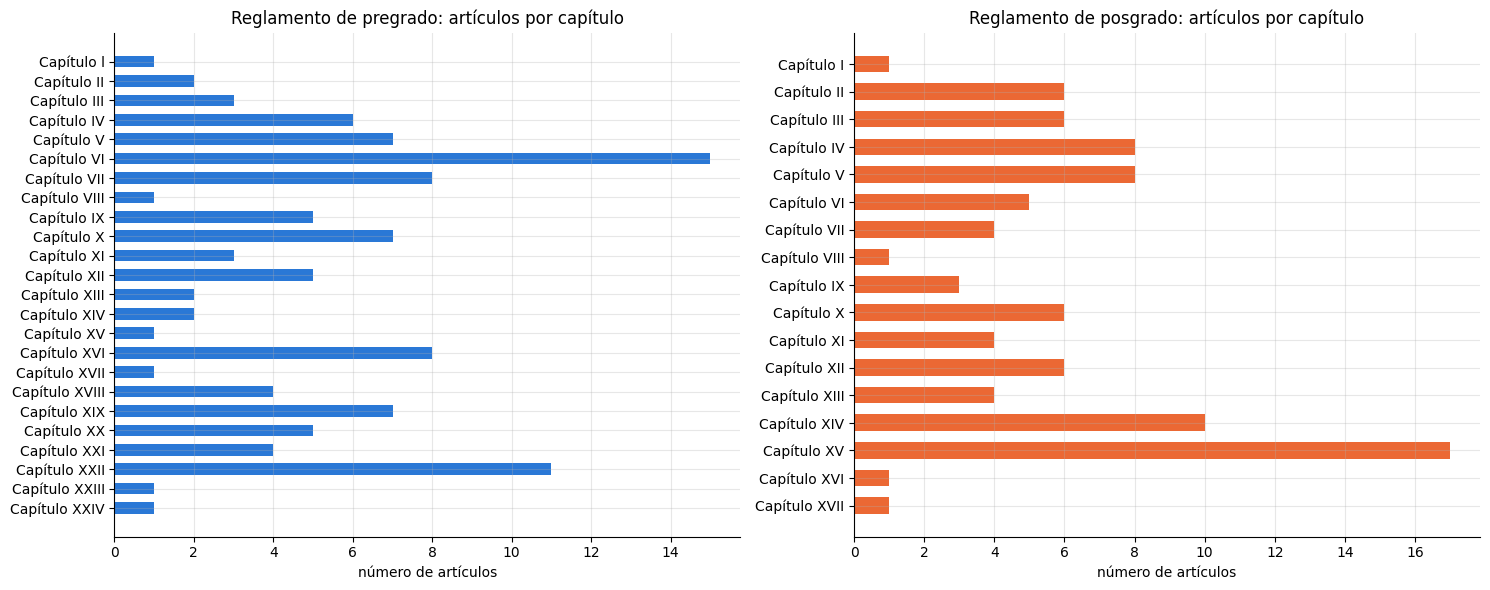

,articulos,palabras_total,palabras_mediana,palabras_max
doc,,,,
posgrado,91,12141,76.0,1642
pregrado,110,12833,67.5,1454


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for ax, clave in zip(axes, DOCUMENTOS):
    conteo = df_art[df_art['doc'] == clave].groupby('capitulo', sort=False)['articulo'].count()
    ax.barh(conteo.index[::-1], conteo.values[::-1], color=COLOR_DOC[clave], height=0.6)
    ax.set_title(f"{DOCUMENTOS[clave]['nombre']}: artículos por capítulo")
    ax.set_xlabel('número de artículos')
plt.tight_layout()
plt.show()

resumen = df_art.groupby('doc').agg(articulos=('articulo', 'count'), palabras_total=('palabras', 'sum'),
                                    palabras_mediana=('palabras', 'median'), palabras_max=('palabras', 'max'))
resumen

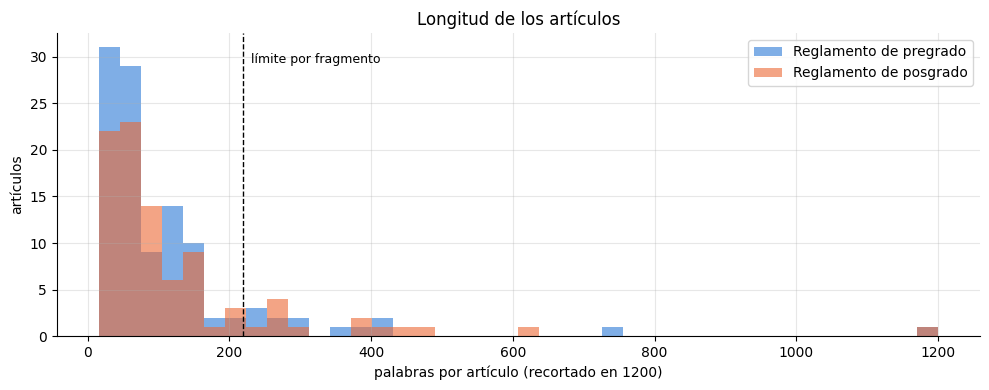

Artículos más largos:
     doc  articulo      capitulo  palabras
posgrado        60 Capítulo XIII      1642
pregrado        95  Capítulo XXI      1454
pregrado        64 Capítulo XIII       752
posgrado        38  Capítulo VII       616
posgrado        37  Capítulo VII       483
posgrado        10  Capítulo III       433


In [20]:
fig, ax = plt.subplots(figsize=(10, 4))
for clave in DOCUMENTOS:
    datos = df_art[df_art['doc'] == clave]['palabras']
    ax.hist(datos.clip(upper=1200), bins=40, alpha=0.6, color=COLOR_DOC[clave], label=DOCUMENTOS[clave]['nombre'])
ax.axvline(CONFIG['max_palabras_articulo'], color='black', linestyle='--', linewidth=1)
ax.text(CONFIG['max_palabras_articulo'] + 10, ax.get_ylim()[1] * 0.9, 'límite por fragmento', fontsize=9)
ax.set_xlabel('palabras por artículo (recortado en 1200)')
ax.set_ylabel('artículos')
ax.set_title('Longitud de los artículos')
ax.legend()
plt.tight_layout()
plt.show()

print('Artículos más largos:')
print(df_art.sort_values('palabras', ascending=False)[['doc', 'articulo', 'capitulo', 'palabras']].head(6).to_string(index=False))

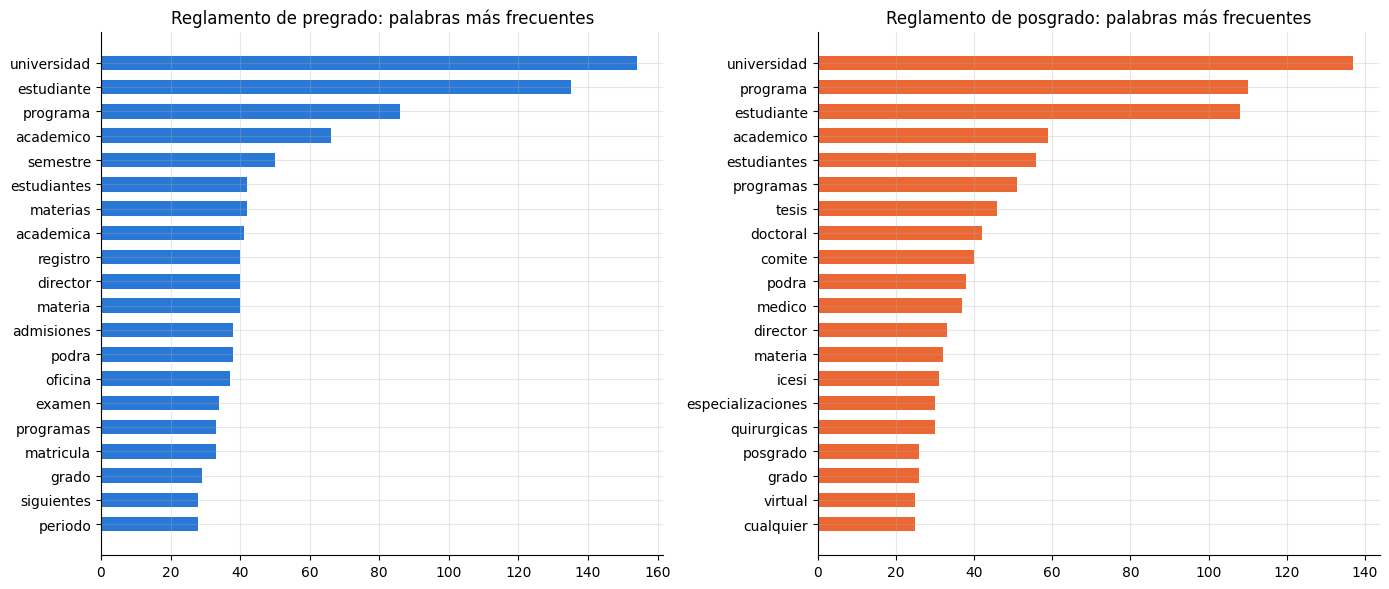

In [21]:
STOP = set('''
de la que el en y a los del se las por un para con no una su al lo como mas o pero sus le ya entre cuando todo
esta este esto ser es son fue han ha sera seran sin sobre tambien hasta hay donde quien desde todos durante
estos estas cual cuales siempre puede pueden debe deberan debera dicho dicha cada otro otra otros otras segun
articulo paragrafo literal numeral presente mismo misma dentro caso casos forma parte
'''.split())


def sin_tildes(s):
    return ''.join(c for c in unicodedata.normalize('NFD', s) if unicodedata.category(c) != 'Mn')


def tokens(texto):
    return [w for w in re.findall(r'[a-zñ0-9]+', sin_tildes(texto.lower())) if w not in STOP and len(w) > 2]


fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, clave in zip(axes, DOCUMENTOS):
    frecuentes = Counter(w for t in df_art[df_art['doc'] == clave]['texto'] for w in tokens(t)).most_common(20)[::-1]
    ax.barh([w for w, _ in frecuentes], [c for _, c in frecuentes], color=COLOR_DOC[clave], height=0.6)
    ax.set_title(f"{DOCUMENTOS[clave]['nombre']}: palabras más frecuentes")
plt.tight_layout()
plt.show()

### Análisis

- La separación encontró todos los artículos: 110 en pregrado y 91 en posgrado, sin saltos en la numeración. El de pregrado tiene 37 páginas y 24 capítulos, y el de posgrado 35 páginas y 17 capítulos.
- Los dos tienen un tamaño parecido, unas 12.000 palabras cada uno. Un artículo normal tiene entre 70 y 80 palabras, pero hay algunos muy largos. Los más largos son los de faltas disciplinarias: el 60 de posgrado (1.642 palabras) y el 95 de pregrado (1.454 palabras).
- En pregrado el capítulo con más artículos es el VI (equivalencias, traslados, transferencias y simultaneidad), con 15. En posgrado es el XV, el del programa de doctorado, con 17.
- Las palabras más comunes son casi las mismas en los dos ("universidad", "estudiante", "programa", "académico"). Las diferencias aparecen más abajo: en pregrado salen "semestre", "materias", "registro" y "matrícula", y en posgrado "tesis", "doctoral", "médico", "quirúrgicas", "especializaciones" y "virtual", porque ese reglamento tiene reglas especiales para esos programas.
- Un detalle: en el PDF de pregrado el capítulo I sale como "Capítulo l" (con ele minúscula) por la forma en que se extrae el texto. No cambia los resultados.

## 3. Fragmentación

Los modelos no pueden recibir un reglamento entero, así que hay que partirlo en pedazos. Probamos dos formas:

- Tamaño fijo: pedazos de 900 caracteres, que se montan 150 caracteres con el anterior, sin mirar dónde empieza o termina cada artículo. Es la forma más común.
- Por artículo: cada artículo es un pedazo. Si un artículo tiene más de 220 palabras, se parte en pedazos de 220 palabras que se montan 50 palabras, y todos conservan el número del artículo.

A cada pedazo le pusimos al inicio el nombre del reglamento, y en la forma por artículo también el capítulo y el número. La idea es que cada pedazo diga de dónde viene, para que sea más fácil separar pregrado de posgrado.

Con tamaño fijo un pedazo puede quedar con partes de varios artículos, así que guardamos todos los artículos que toca.

In [22]:
NOMBRE_CORTO = {'pregrado': 'Reglamento de pregrado', 'posgrado': 'Reglamento de posgrado'}


def fragmentos_tamano_fijo(clave):
    texto = textos_completos[clave]
    arts = df_art[df_art['doc'] == clave]
    inicio_texto = int(arts['inicio'].min())
    paso = CONFIG['chunk_chars'] - CONFIG['chunk_solape']
    salida = []
    for s in range(inicio_texto, len(texto), paso):
        e = min(s + CONFIG['chunk_chars'], len(texto))
        cubiertos = arts[(arts['inicio'] < e) & (arts['fin'] > s)]
        if not len(cubiertos):
            continue
        cuerpo = re.sub(r'\s+', ' ', texto[s:e]).strip()
        nums = [int(n) for n in cubiertos['articulo']]
        etiqueta = f"Artículo {nums[0]}" if len(nums) == 1 else f"Artículos {nums[0]} a {nums[-1]}"
        salida.append({'doc': clave, 'articulos': nums, 'etiqueta': etiqueta, 'pagina': int(cubiertos.iloc[0]['pagina']),
                       'cuerpo': cuerpo, 'texto': f"{NOMBRE_CORTO[clave]}.\n{cuerpo}"})
        if e == len(texto):
            break
    return salida


def fragmentos_por_articulo(clave):
    salida = []
    tam, solape = CONFIG['max_palabras_articulo'], CONFIG['solape_palabras']
    for _, a in df_art[df_art['doc'] == clave].iterrows():
        palabras = a['texto'].split()
        trozos = [palabras] if len(palabras) <= tam else \
            [palabras[i:i + tam] for i in range(0, max(len(palabras) - solape, 1), tam - solape)]
        for trozo in trozos:
            cuerpo = ' '.join(trozo)
            encabezado = f"{NOMBRE_CORTO[clave]}. {a['capitulo']}. Artículo {a['articulo']}."
            salida.append({'doc': clave, 'articulos': [int(a['articulo'])], 'etiqueta': f"Artículo {a['articulo']}",
                           'pagina': int(a['pagina']), 'cuerpo': cuerpo, 'texto': f"{encabezado}\n{cuerpo}"})
    return salida


FRAGMENTOS = {
    'Tamaño fijo': [f for c in DOCUMENTOS for f in fragmentos_tamano_fijo(c)],
    'Por artículo': [f for c in DOCUMENTOS for f in fragmentos_por_articulo(c)],
}
for nombre, frs in FRAGMENTOS.items():
    largos = [len(f['texto'].split()) for f in frs]
    varios = np.mean([len(f['articulos']) > 1 for f in frs]) * 100
    print(f"{nombre}: {len(frs)} fragmentos | palabras por fragmento: mediana {np.median(largos):.0f}, "
          f"máximo {max(largos)} | fragmentos que mezclan varios artículos: {varios:.0f}%")

print('\nEjemplo de fragmento por artículo:\n')
print(FRAGMENTOS['Por artículo'][5]['texto'][:500])

Tamaño fijo: 219 fragmentos | palabras por fragmento: mediana 141, máximo 156 | fragmentos que mezclan varios artículos: 66%
Por artículo: 254 fragmentos | palabras por fragmento: mediana 95, máximo 227 | fragmentos que mezclan varios artículos: 0%

Ejemplo de fragmento por artículo:

Reglamento de pregrado. Capítulo III. Artículo 5.
que lo acrediten como estudiante. l) Formar asociaciones de estudiantes que propendan al desarrollo personal e institucional. m) Representar a los estudiantes o ser representados por uno de ellos ante el Consejo Académico de la Universidad y demás organismos en los cuales esté prevista la presencia de estudiantes. n) Participar en el proceso de selección y elección de los representantes estudiantiles. o) Recibir oportunamente información de la la


## 4. Embeddings y métodos de búsqueda

Probamos dos modelos de embeddings que funcionan en español y corren sin problema en Colab:

- paraphrase-multilingual-MiniLM-L12-v2: es liviano y muy usado, pero solo lee los primeros 128 tokens de cada texto.
- multilingual-e5-small: tiene un tamaño parecido, lee hasta 512 tokens y fue entrenado para búsqueda. Pide poner "query: " antes de las preguntas y "passage: " antes de los textos.

Primero revisamos cuántos pedazos quedan cortados por el límite de cada modelo, porque lo que pasa del límite no se tiene en cuenta al buscar.

modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/3.89k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/645 [00:00<?, ?B/s]

...

tokenizer.json: downloading bytes:           |  0.00B            

special_tokens_map.json:   0%|          | 0.00/167 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/200 [00:00<?, ?B/s]

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (213 > 128). Running this sequence through the model will result in indexing errors


E5 small multilingüe: dimensión 384, máximo de tokens 512


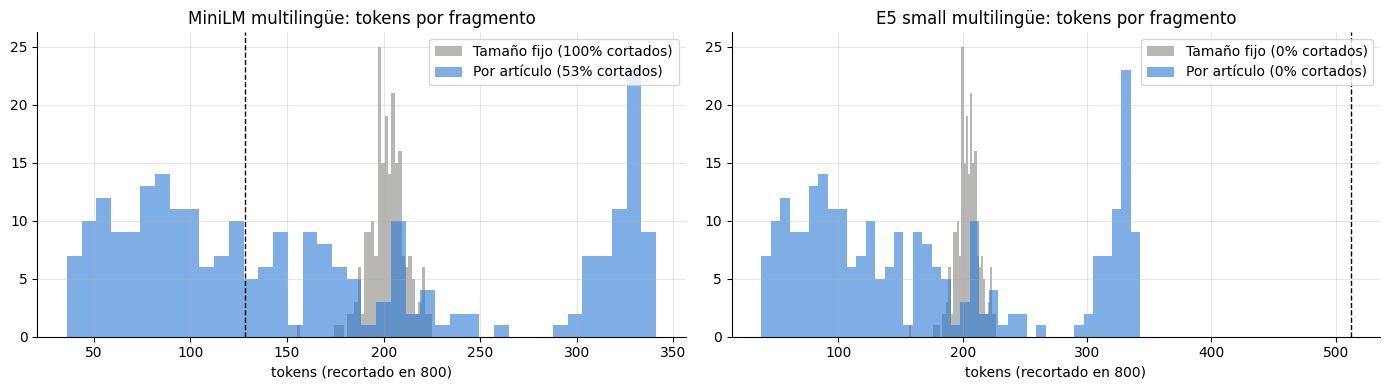

In [23]:
from sentence_transformers import SentenceTransformer

EMBEDDERS = {
    'MiniLM multilingüe': {'modelo': 'sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2', 'q': '', 'p': ''},
    'E5 small multilingüe': {'modelo': 'intfloat/multilingual-e5-small', 'q': 'query: ', 'p': 'passage: '},
}
for nombre, cfg in EMBEDDERS.items():
    cfg['st'] = SentenceTransformer(cfg['modelo'], device=DEVICE)
    print(f"{nombre}: dimensión {cfg['st'].get_sentence_embedding_dimension()}, máximo de tokens {cfg['st'].max_seq_length}")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, (nombre, cfg) in zip(axes, EMBEDDERS.items()):
    tok = cfg['st'].tokenizer
    for estrategia, color in [('Tamaño fijo', '#898781'), ('Por artículo', '#2a78d6')]:
        largos = [len(tok(cfg['p'] + f['texto'])['input_ids']) for f in FRAGMENTOS[estrategia]]
        cortados = np.mean(np.array(largos) > cfg['st'].max_seq_length) * 100
        ax.hist(np.clip(largos, 0, 800), bins=40, alpha=0.6, color=color, label=f"{estrategia} ({cortados:.0f}% cortados)")
    ax.axvline(cfg['st'].max_seq_length, color='black', linestyle='--', linewidth=1)
    ax.set_title(f"{nombre}: tokens por fragmento")
    ax.set_xlabel('tokens (recortado en 800)')
    ax.legend()
plt.tight_layout()
plt.show()

### Métodos de búsqueda

- Con embeddings: se compara el embedding de la pregunta con el de cada pedazo y se toman los más parecidos.
- BM25: busca por palabras, como un buscador normal. Les da más peso a las palabras que coinciden y que no se repiten mucho en el documento. Sirve para términos exactos como "supletorio" o "cum laude".
- Mezcla (híbrido): junta las dos listas anteriores. Cada pedazo recibe puntos según el puesto en que quedó en cada lista y los puntos se suman (Reciprocal Rank Fusion).
- Mezcla con re-ranker: toma los 20 primeros de la mezcla y los vuelve a ordenar con un modelo que lee la pregunta y el pedazo al mismo tiempo (un cross-encoder). Es más preciso pero más lento, por eso solo se usa con pocos candidatos.

La búsqueda híbrida y el re-ranker no los vimos en clase. También se puede filtrar por reglamento, que es lo que hace el chatbot cuando el usuario escoge pregrado o posgrado.

In [24]:
from sentence_transformers import CrossEncoder

RERANKER = CrossEncoder(CONFIG['reranker'], device=DEVICE, max_length=512)


class BM25:
    def __init__(self, textos, k1=1.5, b=0.75):
        self.docs = [Counter(tokens(t)) for t in textos]
        self.largos = np.array([sum(d.values()) for d in self.docs], dtype=float)
        self.promedio = self.largos.mean()
        n = len(self.docs)
        df = Counter(w for d in self.docs for w in d)
        self.idf = {w: math.log(1 + (n - c + 0.5) / (c + 0.5)) for w, c in df.items()}
        self.k1, self.b = k1, b

    def puntajes(self, pregunta):
        s = np.zeros(len(self.docs))
        for w in set(tokens(pregunta)):
            if w not in self.idf:
                continue
            f = np.array([d.get(w, 0) for d in self.docs], dtype=float)
            s += self.idf[w] * f * (self.k1 + 1) / (f + self.k1 * (1 - self.b + self.b * self.largos / self.promedio))
        return s


class Indice:
    def __init__(self, fragmentos, nombre_embedder):
        self.fragmentos = fragmentos
        self.cfg = EMBEDDERS[nombre_embedder]
        textos = [self.cfg['p'] + f['texto'] for f in fragmentos]
        self.E = self.cfg['st'].encode(textos, batch_size=32, normalize_embeddings=True, show_progress_bar=False)
        self.bm25 = BM25([f['texto'] for f in fragmentos])
        self.docs = np.array([f['doc'] for f in fragmentos])

    def buscar(self, pregunta, metodo='hibrido', k=5, filtro=None):
        validos = np.where(self.docs == filtro)[0] if filtro in DOCUMENTOS else np.arange(len(self.fragmentos))
        if metodo in ('denso', 'hibrido', 'hibrido_rerank'):
            q = self.cfg['st'].encode([self.cfg['q'] + pregunta], normalize_embeddings=True, show_progress_bar=False)[0]
            denso = validos[np.argsort(-(self.E[validos] @ q))]
        if metodo in ('bm25', 'hibrido', 'hibrido_rerank'):
            bm = validos[np.argsort(-self.bm25.puntajes(pregunta)[validos], kind='stable')]
        if metodo == 'denso':
            orden = list(denso)
        elif metodo == 'bm25':
            orden = list(bm)
        else:
            rrf = Counter()
            for lista in (denso, bm):
                for pos, idx in enumerate(lista):
                    rrf[idx] += 1 / (60 + pos + 1)
            orden = [idx for idx, _ in rrf.most_common()]
            if metodo == 'hibrido_rerank':
                candidatos = orden[:CONFIG['n_candidatos']]
                s = RERANKER.predict([(pregunta, self.fragmentos[i]['texto']) for i in candidatos], show_progress_bar=False)
                orden = [candidatos[i] for i in np.argsort(-np.asarray(s))] + orden[CONFIG['n_candidatos']:]
        return orden[:k]


INDICES = {}
for estrategia, frs in FRAGMENTOS.items():
    for nombre_emb in EMBEDDERS:
        inicio = time.time()
        INDICES[(estrategia, nombre_emb)] = Indice(frs, nombre_emb)
        print(f"Índice {estrategia} + {nombre_emb}: {len(frs)} fragmentos en {time.time() - inicio:.1f}s")

config.json:   0%|          | 0.00/891 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  471MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/435 [00:00<?, ?B/s]

tokenizer.json: reconstructing file:   0%|          |  0.00B / 17.1MB            

tokenizer.json: downloading bytes:           |  0.00B            

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

Índice Tamaño fijo + MiniLM multilingüe: 219 fragmentos en 2.0s
Índice Tamaño fijo + E5 small multilingüe: 219 fragmentos en 1.0s
Índice Por artículo + MiniLM multilingüe: 254 fragmentos en 0.5s
Índice Por artículo + E5 small multilingüe: 254 fragmentos en 0.9s


### ¿Qué tanto se parecen los dos reglamentos?

Antes de evaluar quisimos ver qué tanto se parecen los artículos de pregrado y de posgrado. Sacamos el embedding de cada artículo y, para cada artículo de pregrado, buscamos el de posgrado más parecido. Si hay muchos casi iguales, al buscador le va a costar saber de cuál reglamento traer la respuesta.

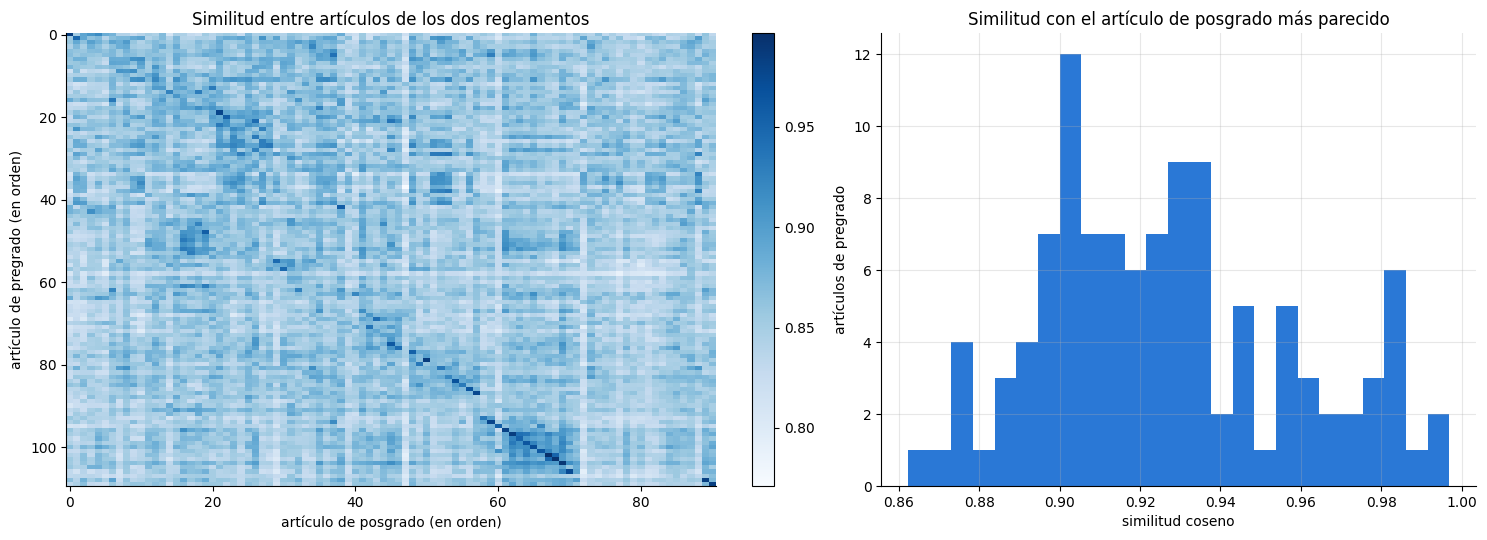

Pares más parecidos (pregrado, posgrado):
  0.997  pregrado art. 103  |  posgrado art.  68
  0.993  pregrado art. 104  |  posgrado art.  69
  0.990  pregrado art. 105  |  posgrado art.  70
  0.986  pregrado art.  80  |  posgrado art.  51
  0.985  pregrado art.   1  |  posgrado art.   1
  0.984  pregrado art.  98  |  posgrado art.  63
  0.983  pregrado art. 110  |  posgrado art.  91
  0.983  pregrado art. 109  |  posgrado art.  90


In [25]:
cfg_e5 = EMBEDDERS['E5 small multilingüe']
emb_art = {c: cfg_e5['st'].encode([cfg_e5['p'] + t for t in df_art[df_art['doc'] == c]['texto']],
                                  normalize_embeddings=True, show_progress_bar=False) for c in DOCUMENTOS}
S = emb_art['pregrado'] @ emb_art['posgrado'].T
nums_pre = df_art[df_art['doc'] == 'pregrado']['articulo'].tolist()
nums_pos = df_art[df_art['doc'] == 'posgrado']['articulo'].tolist()

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5), gridspec_kw={'width_ratios': [1.2, 1]})
im = axes[0].imshow(S, cmap='Blues', aspect='auto', vmin=S.min(), vmax=S.max())
axes[0].set_xlabel('artículo de posgrado (en orden)')
axes[0].set_ylabel('artículo de pregrado (en orden)')
axes[0].set_title('Similitud entre artículos de los dos reglamentos')
axes[0].grid(False)
plt.colorbar(im, ax=axes[0], fraction=0.04)
axes[1].hist(S.max(axis=1), bins=25, color='#2a78d6')
axes[1].set_title('Similitud con el artículo de posgrado más parecido')
axes[1].set_xlabel('similitud coseno')
axes[1].set_ylabel('artículos de pregrado')
plt.tight_layout()
plt.show()

pares = sorted(((S[i, j], nums_pre[i], nums_pos[j]) for i, j in enumerate(S.argmax(axis=1))), reverse=True)[:8]
print('Pares más parecidos (pregrado, posgrado):')
for s, a, b in pares:
    print(f"  {s:.3f}  pregrado art. {a:>3}  |  posgrado art. {b:>3}")

### Análisis

- Con tamaño fijo salieron 219 pedazos y por artículo 254. Con tamaño fijo, el 66 % de los pedazos tiene partes de dos o más artículos.
- MiniLM corta el 100 % de los pedazos de tamaño fijo y el 53 % de los pedazos por artículo, porque solo lee 128 tokens. O sea que en la mayoría de los casos solo ve el comienzo del texto. E5 no corta ninguno.
- Los dos reglamentos se parecen bastante. Todos los artículos de pregrado tienen algún artículo de posgrado con similitud mayor a 0,86, aunque hay que tener en cuenta que E5 suele dar similitudes altas en general. En el mapa de calor se ve una diagonal al final: los artículos del procedimiento disciplinario (103 a 105 de pregrado y 68 a 70 de posgrado) y los de normas de excepción y vigencia son casi iguales, con similitudes entre 0,98 y 0,997. En esos temas da casi lo mismo cuál reglamento se use, pero en temas como la asistencia o las notas la diferencia sí importa.

## 5. Evaluación de la búsqueda

Para medir la búsqueda armamos 20 preguntas como las haría un estudiante, cada una con el reglamento y los artículos donde está la respuesta. Las sacamos leyendo los reglamentos. También pusimos tres preguntas que no se pueden responder con los reglamentos, para usarlas en la sección 6.

Para cada pregunta miramos en qué puesto sale el primer pedazo correcto (del reglamento correcto y con alguno de los artículos esperados). Con eso calculamos:

- Acierto en 1, 3 y 5: porcentaje de preguntas en las que un pedazo correcto sale entre los primeros 1, 3 o 5 resultados.
- MRR: el promedio de 1 dividido entre el puesto del primer pedazo correcto. Si siempre sale de primero vale 1, y si siempre sale de segundo vale 0,5.
- Confusión de reglamento: porcentaje de preguntas en las que el primer resultado viene del reglamento equivocado.

Cada pregunta tiene también una palabra clave, que usamos en la sección 6 para revisar si la respuesta trae el dato correcto.

In [26]:
EVAL = [
    # Pregrado
    {'pregunta': '¿Cuál es la nota mínima para aprobar una materia en pregrado?', 'doc': 'pregrado', 'articulos': [70], 'clave': ['3,0', '3.0', 'tres']},
    {'pregunta': '¿Qué porcentaje de asistencia necesito para no perder una materia por fallas en pregrado?', 'doc': 'pregrado', 'articulos': [70], 'clave': ['80']},
    {'pregunta': '¿Hasta cuándo puedo cancelar una materia sin pagar nada?', 'doc': 'pregrado', 'articulos': [50, 53], 'clave': ['dos semanas', '2 semanas', 'segunda semana']},
    {'pregunta': '¿Cuántas veces puedo cancelar la misma materia en pregrado?', 'doc': 'pregrado', 'articulos': [54], 'clave': ['dos veces', '2 veces']},
    {'pregunta': '¿Con qué promedio quedo en prueba académica?', 'doc': 'pregrado', 'articulos': [66, 67], 'clave': ['3,3', '3.3', '3,4', '3.4']},
    {'pregunta': '¿Qué tengo que hacer para presentar un examen supletorio en pregrado?', 'doc': 'pregrado', 'articulos': [64], 'clave': ['dos días hábiles', '2 días hábiles']},
    {'pregunta': '¿Qué promedio necesito para graduarme cum laude?', 'doc': 'pregrado', 'articulos': [83], 'clave': ['4,3', '4.3']},
    {'pregunta': '¿Qué pasa si un profesor descubre que copié en un examen?', 'doc': 'pregrado', 'articulos': [95, 99], 'clave': ['0,0', '0.0', 'cero']},
    {'pregunta': '¿Cuántos días tengo para reclamar una nota en pregrado?', 'doc': 'pregrado', 'articulos': [77], 'clave': ['tres días', '3 días']},
    {'pregunta': '¿Puedo estudiar dos carreras al mismo tiempo?', 'doc': 'pregrado', 'articulos': [31, 32], 'clave': ['simultane']},
    {'pregunta': '¿Puedo volver a la universidad si me retiré hace varios años?', 'doc': 'pregrado', 'articulos': [11, 12], 'clave': ['cinco años', '5 años']},
    # Posgrado
    {'pregunta': '¿Cuál es la nota mínima aprobatoria en posgrado?', 'doc': 'posgrado', 'articulos': [44], 'clave': ['3,0', '3.0', 'tres']},
    {'pregunta': '¿Qué porcentaje de asistencia se exige en un posgrado?', 'doc': 'posgrado', 'articulos': [44], 'clave': ['70']},
    {'pregunta': '¿Hasta cuándo puedo cancelar un curso en la maestría?', 'doc': 'posgrado', 'articulos': [18], 'clave': ['anterior a la última', 'última clase', 'ultima clase']},
    {'pregunta': '¿Con qué promedio pierdo la calidad de estudiante de posgrado?', 'doc': 'posgrado', 'articulos': [36], 'clave': ['3,5', '3.5']},
    {'pregunta': '¿Cuál es el plazo para pedir un examen supletorio en posgrado?', 'doc': 'posgrado', 'articulos': [41], 'clave': ['8 días', 'ocho días']},
    {'pregunta': '¿Usar inteligencia artificial en un trabajo de posgrado se considera fraude?', 'doc': 'posgrado', 'articulos': [60], 'clave': ['inteligencia artificial', 'ia generativa']},
    {'pregunta': '¿Cómo reclamo una calificación en posgrado?', 'doc': 'posgrado', 'articulos': [47], 'clave': ['8 días', 'ocho días']},
    {'pregunta': 'Si no terminé el trabajo de grado, ¿cuánto tiempo extra tengo en posgrado?', 'doc': 'posgrado', 'articulos': [21], 'clave': ['un período', 'un periodo', 'período académico', 'periodo académico']},
    {'pregunta': '¿Qué porcentaje de créditos puedo homologar de otra universidad en posgrado?', 'doc': 'posgrado', 'articulos': [26], 'clave': ['25']},
    # Fuera de los reglamentos
    {'pregunta': '¿Cuál es el horario de la biblioteca?', 'doc': None, 'articulos': [], 'clave': []},
    {'pregunta': '¿Cuánto cuesta la matrícula de Ingeniería de Sistemas este semestre?', 'doc': None, 'articulos': [], 'clave': []},
    {'pregunta': '¿Quién es el rector de la Universidad Nacional?', 'doc': None, 'articulos': [], 'clave': []},
]
EVAL_DOMINIO = [e for e in EVAL if e['doc']]
print(f"Preguntas: {len(EVAL)} ({sum(e['doc'] == 'pregrado' for e in EVAL)} de pregrado, "
      f"{sum(e['doc'] == 'posgrado' for e in EVAL)} de posgrado, {sum(e['doc'] is None for e in EVAL)} fuera de los reglamentos)")

# Verificación: inicio de los artículos esperados, para revisar que las etiquetas estén bien
for e in EVAL_DOMINIO[:3] + EVAL_DOMINIO[11:13]:
    for n in e['articulos'][:1]:
        f = df_art[(df_art['doc'] == e['doc']) & (df_art['articulo'] == n)]
        texto = f.iloc[0]['texto'][:160] if len(f) else 'NO ENCONTRADO'
        print(f"\n{e['pregunta']}\n  -> {e['doc']} art. {n}: {texto}")

Preguntas: 23 (11 de pregrado, 9 de posgrado, 3 fuera de los reglamentos)

¿Cuál es la nota mínima para aprobar una materia en pregrado?
  -> pregrado art. 70: ARTÍCULO 70. Las calificaciones numéricas que se aplican en cada evaluación, como en la 
nota definitiva de cada materia, y en el cálculo del promedio acumulado

¿Qué porcentaje de asistencia necesito para no perder una materia por fallas en pregrado?
  -> pregrado art. 70: ARTÍCULO 70. Las calificaciones numéricas que se aplican en cada evaluación, como en la 
nota definitiva de cada materia, y en el cálculo del promedio acumulado

¿Hasta cuándo puedo cancelar una materia sin pagar nada?
  -> pregrado art. 50: ARTÍCULO 50. El estudiante podrá cancelar directamente su matrícula o algunas materias 
ante la oficina de Admisiones y Registro durante las dos primeras semana

¿Cuál es la nota mínima aprobatoria en posgrado?
  -> posgrado art. 44: ARTÍCULO 44. Las calificaciones se aplicarán en la Universidad Icesi para cada evaluación

fragmentacion           embeddings  acierto@1  acierto@3  acierto@5   MRR  confusion_%
  Tamaño fijo   MiniLM multilingüe       25.0       45.0       60.0 0.408         45.0
  Tamaño fijo E5 small multilingüe       70.0       85.0       85.0 0.767          5.0
 Por artículo   MiniLM multilingüe       25.0       60.0       70.0 0.446         45.0
 Por artículo E5 small multilingüe       50.0       85.0       95.0 0.681         25.0


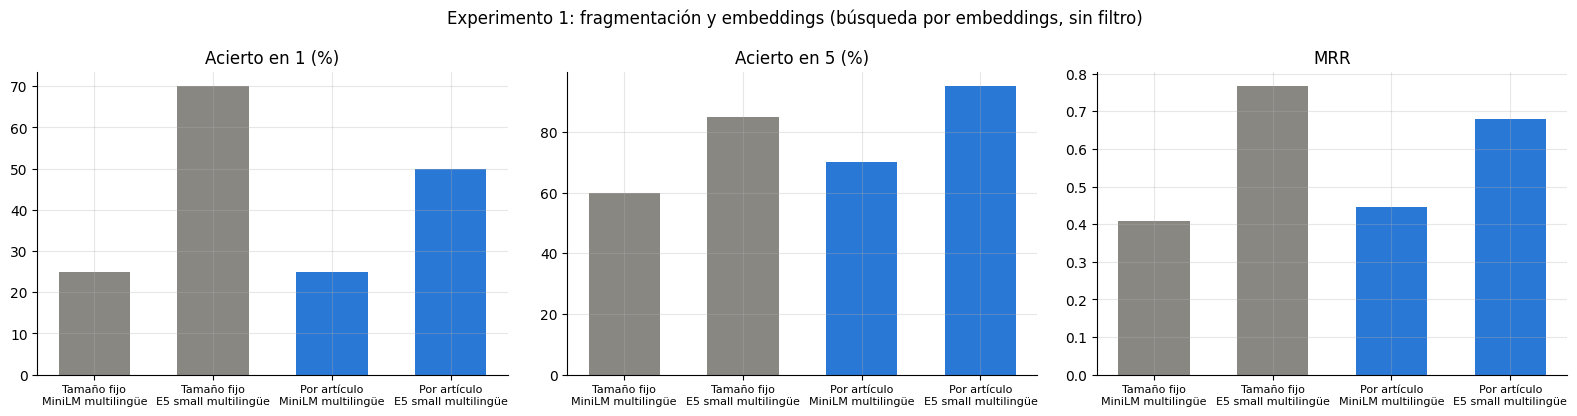


Mejor combinación: ('Tamaño fijo', 'E5 small multilingüe')


In [27]:
def posicion_correcta(indice, resultados, item):
    for pos, idx in enumerate(resultados, 1):
        f = indice.fragmentos[idx]
        if f['doc'] == item['doc'] and set(f['articulos']) & set(item['articulos']):
            return pos
    return None


def evaluar_busqueda(indice, metodo, con_filtro):
    filas = []
    for item in EVAL_DOMINIO:
        res = indice.buscar(item['pregunta'], metodo=metodo, k=10, filtro=item['doc'] if con_filtro else None)
        pos = posicion_correcta(indice, res, item)
        filas.append({'pos': pos, 'confusion': indice.fragmentos[res[0]]['doc'] != item['doc']})
    pos = [f['pos'] for f in filas]
    return {
        'acierto@1': 100 * np.mean([p == 1 for p in pos]),
        'acierto@3': 100 * np.mean([p is not None and p <= 3 for p in pos]),
        'acierto@5': 100 * np.mean([p is not None and p <= 5 for p in pos]),
        'MRR': np.mean([1 / p if p else 0 for p in pos]),
        'confusion_%': 100 * np.mean([f['confusion'] for f in filas]),
    }


# Experimento 1: fragmentación x modelo de embeddings, con búsqueda por embeddings y sin filtro
filas = []
for (estrategia, nombre_emb), indice in INDICES.items():
    filas.append({'fragmentacion': estrategia, 'embeddings': nombre_emb, **evaluar_busqueda(indice, 'denso', False)})
exp1 = pd.DataFrame(filas)
print(exp1.round(3).to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))
etiquetas = [f"{r.fragmentacion}\n{r.embeddings}" for r in exp1.itertuples()]
colores = ['#898781' if r.fragmentacion == 'Tamaño fijo' else '#2a78d6' for r in exp1.itertuples()]
for ax, col, titulo in zip(axes, ['acierto@1', 'acierto@5', 'MRR'], ['Acierto en 1 (%)', 'Acierto en 5 (%)', 'MRR']):
    ax.bar(range(len(exp1)), exp1[col], color=colores, width=0.6)
    ax.set_xticks(range(len(exp1)))
    ax.set_xticklabels(etiquetas, fontsize=8)
    ax.set_title(titulo)
plt.suptitle('Experimento 1: fragmentación y embeddings (búsqueda por embeddings, sin filtro)')
plt.tight_layout()
plt.show()

mejor = exp1.sort_values(['MRR', 'acierto@5'], ascending=False).iloc[0]
MEJOR_INDICE_CLAVE = (mejor['fragmentacion'], mejor['embeddings'])
print(f"\nMejor combinación: {MEJOR_INDICE_CLAVE}")

             metodo     filtro  acierto@1  acierto@3  acierto@5   MRR  confusion_%  segundos_por_pregunta
         Embeddings sin filtro       70.0       85.0       85.0 0.767          5.0                  0.011
         Embeddings con filtro       70.0       85.0       90.0 0.785          0.0                  0.012
               BM25 sin filtro       40.0       65.0       80.0 0.548         35.0                  0.000
               BM25 con filtro       55.0       75.0       85.0 0.671          0.0                  0.000
            Híbrido sin filtro       65.0       85.0       90.0 0.742         15.0                  0.012
            Híbrido con filtro       75.0       90.0       95.0 0.838          0.0                  0.011
Híbrido + re-ranker sin filtro       80.0      100.0      100.0 0.883         10.0                  0.104
Híbrido + re-ranker con filtro       85.0      100.0      100.0 0.917          0.0                  0.110


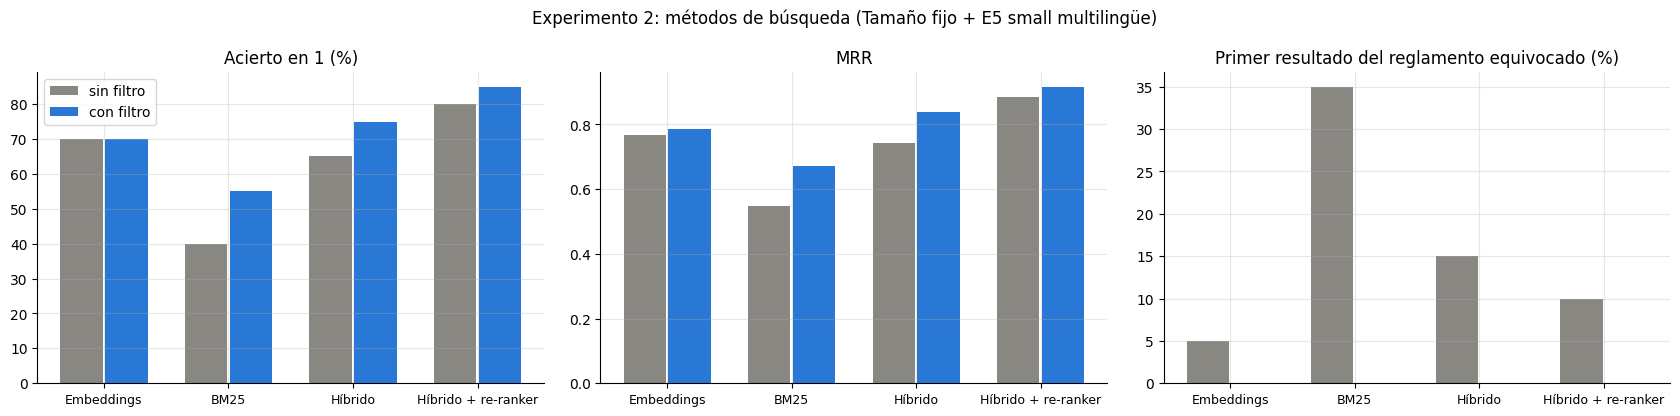


Mejor método con filtro: Híbrido + re-ranker


In [28]:
# Experimento 2: métodos de búsqueda sobre la mejor combinación, con y sin filtro por reglamento
METODOS = {'denso': 'Embeddings', 'bm25': 'BM25', 'hibrido': 'Híbrido', 'hibrido_rerank': 'Híbrido + re-ranker'}
indice = INDICES[MEJOR_INDICE_CLAVE]
filas = []
for metodo, nombre in METODOS.items():
    for con_filtro in (False, True):
        inicio = time.time()
        r = evaluar_busqueda(indice, metodo, con_filtro)
        filas.append({'metodo': nombre, 'filtro': 'con filtro' if con_filtro else 'sin filtro', **r,
                      'segundos_por_pregunta': (time.time() - inicio) / len(EVAL_DOMINIO)})
exp2 = pd.DataFrame(filas)
print(exp2.round(3).to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(17, 4.2))
x = np.arange(len(METODOS))
for ax, col, titulo in zip(axes, ['acierto@1', 'MRR', 'confusion_%'],
                           ['Acierto en 1 (%)', 'MRR', 'Primer resultado del reglamento equivocado (%)']):
    for j, (filtro, color) in enumerate([('sin filtro', '#898781'), ('con filtro', '#2a78d6')]):
        valores = exp2[exp2['filtro'] == filtro][col].values
        ax.bar(x + (j - 0.5) * 0.36, valores, width=0.34, color=color, label=filtro)
    ax.set_xticks(x)
    ax.set_xticklabels(METODOS.values(), fontsize=9)
    ax.set_title(titulo)
axes[0].legend()
plt.suptitle(f'Experimento 2: métodos de búsqueda ({MEJOR_INDICE_CLAVE[0]} + {MEJOR_INDICE_CLAVE[1]})')
plt.tight_layout()
plt.show()

con_filtro_df = exp2[exp2['filtro'] == 'con filtro'].sort_values(['MRR', 'acierto@1'], ascending=False)
MEJOR_METODO = [k for k, v in METODOS.items() if v == con_filtro_df.iloc[0]['metodo']][0]
print(f"\nMejor método con filtro: {METODOS[MEJOR_METODO]}")

In [29]:
# Detalle por pregunta con el mejor método: dónde falla la búsqueda
detalle = []
for item in EVAL_DOMINIO:
    for con_filtro in (False, True):
        res = indice.buscar(item['pregunta'], metodo=MEJOR_METODO, k=10, filtro=item['doc'] if con_filtro else None)
        primero = indice.fragmentos[res[0]]
        detalle.append({'pregunta': item['pregunta'][:60], 'filtro': con_filtro, 'esperado': f"{item['doc']} {item['articulos']}",
                        'primer_resultado': f"{primero['doc']} {primero['articulos'][:3]}",
                        'posicion_correcta': posicion_correcta(indice, res, item)})
detalle_df = pd.DataFrame(detalle)
detalle_df[detalle_df['filtro'] == False].drop(columns='filtro')

,pregunta,esperado,primer_resultado,posicion_correcta
0,¿Cuál es la nota mínima para aprobar una mater...,pregrado [70],pregrado [70],1
2,¿Qué porcentaje de asistencia necesito para no...,pregrado [70],pregrado [70],1
4,¿Hasta cuándo puedo cancelar una materia sin p...,"pregrado [50, 53]","posgrado [19, 20, 21]",3
6,¿Cuántas veces puedo cancelar la misma materia...,pregrado [54],"pregrado [54, 55]",1
8,¿Con qué promedio quedo en prueba académica?,"pregrado [66, 67]","pregrado [66, 67]",1
10,¿Qué tengo que hacer para presentar un examen ...,pregrado [64],pregrado [64],1
12,¿Qué promedio necesito para graduarme cum laude?,pregrado [83],"pregrado [83, 84]",1
14,¿Qué pasa si un profesor descubre que copié en...,"pregrado [95, 99]","posgrado [63, 64]",2
16,¿Cuántos días tengo para reclamar una nota en ...,pregrado [77],"pregrado [76, 77]",1
18,¿Puedo estudiar dos carreras al mismo tiempo?,"pregrado [31, 32]","pregrado [30, 31, 32]",1


### Análisis

Experimento 1:

- E5 fue mucho mejor que MiniLM con las dos formas de partir el texto. Con tamaño fijo, el acierto en 1 pasó de 25 % a 70 % y el MRR de 0,41 a 0,77. Tiene sentido por lo que vimos antes: MiniLM solo lee el comienzo de cada pedazo.
- Con MiniLM, casi la mitad de las veces (45 %) el primer resultado era del reglamento equivocado.
- Con E5, el tamaño fijo dio mejor MRR (0,77 contra 0,68) y menos confusión de reglamento (5 % contra 25 %), aunque la forma por artículo tuvo mejor acierto en 5 (95 % contra 85 %). Creemos que los pedazos por artículo son cortos y muy parecidos entre los dos reglamentos, mientras que los de tamaño fijo tienen más texto alrededor que ayuda a diferenciarlos. Nos quedamos con tamaño fijo y E5.

Experimento 2:

- BM25 solo fue el peor (MRR de 0,55 sin filtro) y el que más se confundió de reglamento (35 %), porque los dos documentos usan casi las mismas palabras.
- La mezcla mejoró un poco frente a los embeddings solos cuando se usa el filtro (MRR de 0,84 contra 0,79).
- El re-ranker fue el mejor. Con filtro, el pedazo correcto quedó de primero en el 85 % de las preguntas y entre los tres primeros en todas, con un MRR de 0,92. Es más lento (0,1 segundos por pregunta contra 0,01), pero sigue siendo rápido.
- El filtro por reglamento ayuda con todos los métodos porque quita la confusión entre pregrado y posgrado. Por eso dejamos esa opción en el chatbot.
- En la tabla de detalle (sin filtro) hay cuatro preguntas en las que el pedazo correcto no salió de primero. En dos el problema fue el reglamento: en "¿Hasta cuándo puedo cancelar una materia sin pagar nada?" y en "¿Qué pasa si un profesor descubre que copié en un examen?" salieron primero artículos de posgrado. Ninguna de las dos dice si es de pregrado o de posgrado, así que el error se entiende. En las otras dos salió primero otro artículo del mismo reglamento; por ejemplo, en la de inteligencia artificial salió el artículo 64, que habla de qué hacer cuando hay fraude.

## 6. Generación de respuestas con Ollama

Igual que en los notebooks de la sesión, usamos modelos locales con Ollama. Prendemos el servidor de Ollama en segundo plano desde el notebook, para no tener que usar la terminal de Colab.

In [30]:
!sudo apt-get install -y -qq zstd > /dev/null
!if ! type ollama > /dev/null 2>&1; then curl -fsSL https://ollama.com/install.sh | sh > /dev/null; else echo "Ollama ya está instalado."; fi

debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 79, <STDIN> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
>>> Installing ollama to /usr/local
>>> Downloading ollama-linux-amd64.tar.zst
######################################################################## 100.0%
>>> Creating ollama user...
>>> Adding ollama user to video group...
>>> Adding current user to ollama group...
>>> Creating ollama systemd service...
>>> The Ollama API is now available at 127.0.0.1:11434.
>>> Install complete. Run "ollama" from the command line.


In [31]:
def ollama_activo():
    try:
        return requests.get('http://127.0.0.1:11434/api/tags', timeout=2).status_code == 200
    except Exception:
        return False


if not ollama_activo():
    proceso_ollama = subprocess.Popen(['ollama', 'serve'], stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
    for _ in range(60):
        if ollama_activo():
            break
        time.sleep(1)
print(f"Ollama activo: {ollama_activo()}")

for modelo in CONFIG['modelos_llm']:
    inicio = time.time()
    subprocess.run(['ollama', 'pull', modelo], stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL, check=True)
    print(f"Modelo {modelo} listo ({time.time() - inicio:.0f}s)")

Ollama activo: True
Modelo llama3.2:3b listo (32s)
Modelo qwen2.5:3b listo (28s)


### Primero: ¿qué responde el modelo sin RAG?

Antes de conectar el buscador le hicimos dos preguntas al modelo solo, sin documentos, para ver qué pasaba.

In [32]:
from langchain_ollama import ChatOllama


def crear_llm(modelo, max_tokens=None):
    return ChatOllama(model=modelo, temperature=0, num_ctx=4096, num_predict=max_tokens or CONFIG['max_tokens_respuesta'])


llm_base = crear_llm(CONFIG['modelos_llm'][0], max_tokens=150)
for pregunta in ['¿Qué porcentaje de asistencia se exige en un posgrado de la Universidad Icesi?',
                 '¿Cuál es el plazo para pedir un examen supletorio en pregrado en la Universidad Icesi?']:
    print(f"PREGUNTA: {pregunta}\nRESPUESTA SIN RAG: {llm_base.invoke(pregunta).content}\n")

PREGUNTA: ¿Qué porcentaje de asistencia se exige en un posgrado de la Universidad Icesi?
RESPUESTA SIN RAG: Lo siento, pero no tengo acceso a información específica sobre las políticas de asistencia de la Universidad Icesi o cualquier otro instituto educativo. Las políticas de asistencia pueden variar ampliamente entre diferentes instituciones y pueden cambiar con el tiempo.

Para obtener la información más actualizada y precisa sobre las políticas de asistencia de la Universidad Icesi, te recomiendo contactar directamente con la institución a través de su sitio web oficial o comunicándote con su oficina de admisiones o asistencia estudiantil. Ellos podrían proporcionarte la información más actualizada sobre los requisitos de asistencia y cualquier otro detalle relevante.

Si tienes alguna otra pregunta o necesitas ayuda

PREGUNTA: ¿Cuál es el plazo para pedir un examen supletorio en pregrado en la Universidad Icesi?
RESPUESTA SIN RAG: Lo siento, pero no tengo acceso a información espe

### RAG: buscar, armar el contexto y responder

El modelo recibe los pedazos que encontró el buscador, cada uno con un encabezado que dice el reglamento, el artículo y la página. Le pedimos que responda solo con esa información, que diga el artículo y que, si la respuesta no está, conteste con una frase fija. Con esa frase podemos contar cuántas veces el modelo dice que no sabe.

In [33]:
FRASE_NO_SE = 'No encontré esa información en los reglamentos.'
PROMPT_SISTEMA = (
    'Eres un asistente que responde preguntas sobre los reglamentos estudiantiles de la Universidad Icesi. '
    'Responde en español, de forma breve y clara, usando solamente la información de los fragmentos que se te entregan. '
    'Después de cada dato cita entre paréntesis el reglamento y el artículo, por ejemplo (Pregrado, artículo 70). '
    f'Si la respuesta no está en los fragmentos, responde exactamente: "{FRASE_NO_SE}" y no agregues nada más.'
)


def formatear_fragmentos(indice, resultados):
    bloques = []
    for i, idx in enumerate(resultados, 1):
        f = indice.fragmentos[idx]
        bloques.append(f"[{i}] {NOMBRE_CORTO[f['doc']]}, {f['etiqueta']} (página {f['pagina']})\n{f['cuerpo']}")
    return '\n\n'.join(bloques)


def responder_rag(pregunta, llm, indice, filtro=None, metodo=None, k=None):
    resultados = indice.buscar(pregunta, metodo=metodo or MEJOR_METODO, k=k or CONFIG['k_fragmentos'], filtro=filtro)
    contexto = formatear_fragmentos(indice, resultados)
    inicio = time.time()
    respuesta = llm.invoke([('system', PROMPT_SISTEMA),
                            ('user', f"Fragmentos de los reglamentos:\n\n{contexto}\n\nPregunta: {pregunta}")]).content
    return respuesta, resultados, time.time() - inicio


respuesta, resultados, segundos = responder_rag('¿Qué porcentaje de asistencia se exige en un posgrado?',
                                                llm_base, indice, filtro='posgrado')
print(respuesta)
print(f"\n({segundos:.1f}s) Fragmentos usados:", [(indice.fragmentos[i]['doc'], indice.fragmentos[i]['etiqueta']) for i in resultados])

Se exige al menos el 70% de asistencia a las horas programadas para una materia. (Reglamento de posgrado, Artículo 45, f)

(1.1s) Fragmentos usados: [('posgrado', 'Artículos 44 a 45'), ('posgrado', 'Artículo 26'), ('posgrado', 'Artículos 34 a 36'), ('posgrado', 'Artículos 25 a 26')]


### Evaluación de las respuestas

Pasamos todas las preguntas por el sistema completo con cada modelo. Usamos el filtro por reglamento, como lo haría alguien en el chatbot, menos en las preguntas que no están en los reglamentos. Medimos:

- Respuesta correcta: la respuesta trae el dato clave esperado (por ejemplo, "80" en la asistencia de pregrado).
- Cita correcta: la respuesta nombra alguno de los artículos esperados.
- Abstención correcta: en las preguntas que no están en los reglamentos, el modelo contesta que no encontró la información.
- Abstención equivocada: en las preguntas que sí están, el modelo dice que no encontró la información.

In [34]:
def normalizar(t):
    return sin_tildes(t.lower())


def articulos_citados(texto):
    return {int(n) for n in re.findall(r'art(?:iculo|\.)?\s*(\d{1,3})', normalizar(texto))}


def evaluar_generacion(modelo, preguntas):
    llm = crear_llm(modelo)
    filas = []
    for item in preguntas:
        respuesta, _, segundos = responder_rag(item['pregunta'], llm, indice, filtro=item['doc'])
        n = normalizar(respuesta)
        se_abstiene = 'no encontre' in n
        filas.append({'modelo': modelo, 'pregunta': item['pregunta'], 'en_dominio': item['doc'] is not None,
                      'correcta': any(normalizar(c) in n for c in item['clave']) if item['doc'] else np.nan,
                      'cita_correcta': bool(articulos_citados(respuesta) & set(item['articulos'])) if item['doc'] else np.nan,
                      'abstencion': se_abstiene, 'segundos': segundos, 'respuesta': respuesta})
    return filas


if CONFIG['preguntas_generacion']:
    n_por_doc = (CONFIG['preguntas_generacion'] - 2) // 2
    PREGUNTAS_GEN = ([e for e in EVAL if e['doc'] == 'pregrado'][:n_por_doc] +
                     [e for e in EVAL if e['doc'] == 'posgrado'][:n_por_doc] + [e for e in EVAL if e['doc'] is None][:2])
else:
    PREGUNTAS_GEN = EVAL

resultados_gen = []
for modelo in CONFIG['modelos_llm']:
    inicio = time.time()
    resultados_gen += evaluar_generacion(modelo, PREGUNTAS_GEN)
    print(f"{modelo}: {len(PREGUNTAS_GEN)} preguntas en {time.time() - inicio:.0f}s")
gen_df = pd.DataFrame(resultados_gen)

resumen_gen = gen_df.groupby('modelo').apply(lambda g: pd.Series({
    'correctas_%': 100 * g.loc[g['en_dominio'], 'correcta'].astype(float).mean(),
    'cita_correcta_%': 100 * g.loc[g['en_dominio'], 'cita_correcta'].astype(float).mean(),
    'abstencion_correcta_%': 100 * g.loc[~g['en_dominio'], 'abstencion'].mean(),
    'abstencion_equivocada_%': 100 * g.loc[g['en_dominio'], 'abstencion'].mean(),
    'segundos_promedio': g['segundos'].mean(),
}))
resumen_gen.round(1)

llama3.2:3b: 23 preguntas en 47s
qwen2.5:3b: 23 preguntas en 89s


,correctas_%,cita_correcta_%,abstencion_correcta_%,abstencion_equivocada_%,segundos_promedio
modelo,,,,,
llama3.2:3b,75.0,75.0,100.0,5.0,1.9
qwen2.5:3b,65.0,20.0,100.0,20.0,3.7


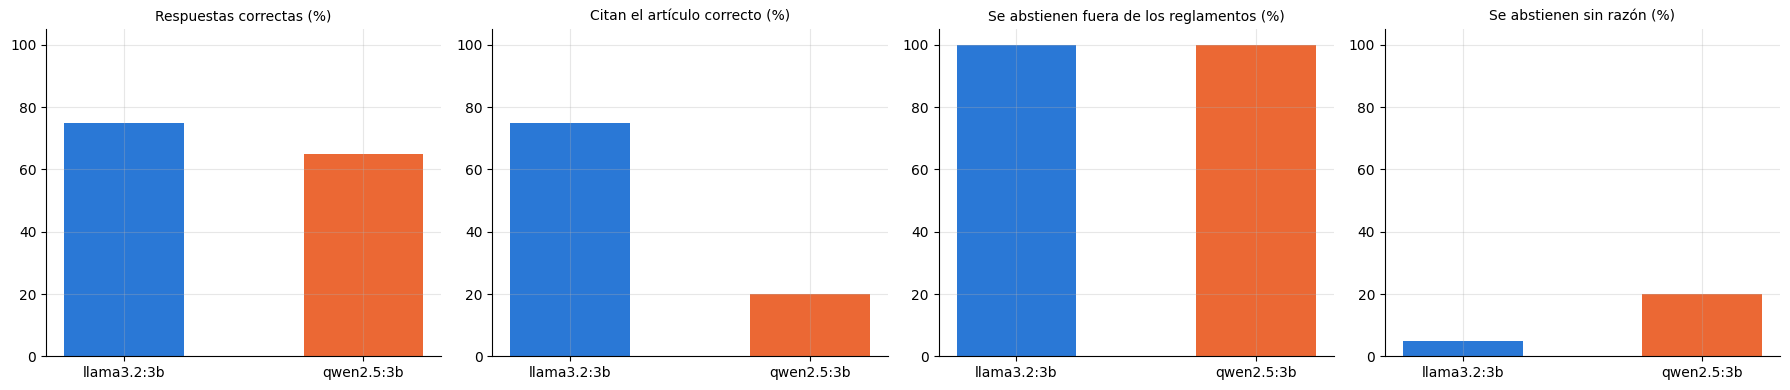

,modelo,pregunta,correcta,cita_correcta,abstencion,respuesta
0,llama3.2:3b,¿Cuál es la nota mínima para aprobar una materia en pregrado?,True,True,False,"Una calificación igual o superior a tres cero (3,0) indica aprobación de la materia. (Pregrado, artículo 70)"
1,llama3.2:3b,¿Qué porcentaje de asistencia necesito para no perder una materia por fallas en pregrado?,True,False,False,"Para no perder una materia por fallas en pregrado, debes asistir al 80% de las horas correspondientes a la materia. (Pregrado, artículo 64, PARÁGRAFO 2º)"
2,llama3.2:3b,¿Hasta cuándo puedo cancelar una materia sin pagar nada?,False,False,False,"Durante la primera semana del período académico de verano, puedes cancelar materias directamente ante la oficina de Admisiones y Registro y el trámite no tendrá ningún costo."
3,llama3.2:3b,¿Cuántas veces puedo cancelar la misma materia en pregrado?,True,True,False,"Una materia podrá ser cancelada sólo dos veces. (Pregrado, artículo 54)"
4,llama3.2:3b,¿Con qué promedio quedo en prueba académica?,True,True,False,"Si el estudiante obtiene un promedio inferior a tres con tres (3,3) al cabo de su segundo semestre de permanencia en la Universidad, quedará en prueba académica. (Pregrado, artículo 67, Literal a))"
5,llama3.2:3b,¿Qué tengo que hacer para presentar un examen supletorio en pregrado?,True,True,False,"Para presentar un examen supletorio en pregrado, el estudiante debe hacer la solicitud dentro de los dos días hábiles siguientes a la realización del examen, mediante comunicación escrita dirigida..."
6,llama3.2:3b,¿Qué promedio necesito para graduarme cum laude?,True,True,False,"Para graduarte cum laude, necesitas un promedio de calificaciones de cuatro con tres (4,3) o superior. (Reglamento de pregrado, Artículo 83)"
7,llama3.2:3b,¿Qué pasa si un profesor descubre que copié en un examen?,True,True,False,"Si un profesor descubre que un estudiante copió en un examen, el profesor debe anular el trabajo en su totalidad, calificarlo con cero (0,0) e informar por escrito al Director de Escuela o Jefe de..."
8,llama3.2:3b,¿Cuántos días tengo para reclamar una nota en pregrado?,True,True,False,"Tres días hábiles. (Pregrado, artículo 77)"
9,llama3.2:3b,¿Puedo estudiar dos carreras al mismo tiempo?,False,True,False,"Sí, puedes estudiar dos carreras al mismo tiempo, siempre y cuando cumplas con los requisitos establecidos en el reglamento. (Pregrado, artículo 32)"


In [35]:
cols = ['correctas_%', 'cita_correcta_%', 'abstencion_correcta_%', 'abstencion_equivocada_%']
titulos = ['Respuestas correctas (%)', 'Citan el artículo correcto (%)', 'Se abstienen fuera de los reglamentos (%)',
           'Se abstienen sin razón (%)']
colores_llm = ['#2a78d6', '#eb6834', '#1baf7a']
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, col, titulo in zip(axes, cols, titulos):
    ax.bar(resumen_gen.index, resumen_gen[col], color=colores_llm[:len(resumen_gen)], width=0.5)
    ax.set_ylim(0, 105)
    ax.set_title(titulo, fontsize=10)
plt.tight_layout()
plt.show()

pd.set_option('display.max_colwidth', 200)
gen_df[['modelo', 'pregunta', 'correcta', 'cita_correcta', 'abstencion', 'respuesta']]

In [36]:
MEJOR_LLM = resumen_gen.sort_values(['correctas_%', 'cita_correcta_%'], ascending=False).index[0]
print(f"Modelo de lenguaje para el chatbot: {MEJOR_LLM}")

Modelo de lenguaje para el chatbot: llama3.2:3b


### Análisis

- Sin RAG, el modelo no inventó: dijo que no tenía información sobre Icesi y recomendó preguntar en la universidad. Es mejor que inventar, pero no le sirve a quien pregunta.
- Con RAG, llama3.2:3b respondió bien 15 de las 20 preguntas (75 %) y citó el artículo correcto en 15. qwen2.5:3b respondió bien 13 (65 %), pero citó bien solo 4 (20 %), porque casi nunca escribe el artículo aunque se lo pedimos.
- Los dos modelos contestaron que no encontraron la información en las tres preguntas que no están en los reglamentos (horario de la biblioteca, precio de la matrícula y rector de otra universidad). No se inventaron nada.
- qwen dijo que no encontraba la información en 4 preguntas que sí estaban, por ejemplo la asistencia en pregrado y la prueba académica. llama lo hizo en 1, la de la nota mínima de posgrado.
- llama también fue el doble de rápido (1,8 segundos por respuesta contra 3,6). Por eso lo usamos en el chatbot.
- Algunos errores vienen de la búsqueda y otros del modelo. En "¿Hasta cuándo puedo cancelar una materia sin pagar nada?" llama tomó la regla del período de verano en vez de la del semestre normal. En otras respuestas el dato está bien pero la cita no: en la asistencia de pregrado dijo el artículo 64 en vez del 70, en la asistencia de posgrado dijo el 45 en vez del 44, y en el promedio de posgrado escribió "Pregrado" aunque el artículo era de posgrado. Esto pasa en parte porque con tamaño fijo muchos pedazos tienen dos artículos y el modelo no siempre sabe de cuál es el dato. En la pregunta de inteligencia artificial la respuesta de llama quedó cortada ("Sí, según el artículo 60, se.").
- La medida automática es estricta. Por ejemplo, llama respondió bien que sí se pueden estudiar dos carreras al mismo tiempo, pero no usó la palabra "simultaneidad" y quedó como incorrecta. Revisando las respuestas a mano, el resultado real es un poco mejor que el de la tabla.

## 7. El buscador como servidor MCP

Igual que en la guía, donde la calculadora y el clima eran servidores MCP, aquí el buscador de los reglamentos es una herramienta MCP llamada buscar_reglamento. Guardamos el índice con la mejor configuración y escribimos un servidor pequeño que lo carga y responde por HTTP en el puerto 9090.

La ventaja es la que vimos en clase: el buscador queda separado de la aplicación. El chatbot lo usa por MCP, pero cualquier otro agente que use MCP podría usarlo igual.

In [37]:
Path('indice').mkdir(exist_ok=True)
json.dump(indice.fragmentos, open('indice/fragmentos.json', 'w', encoding='utf-8'), ensure_ascii=False)
np.save('indice/embeddings.npy', indice.E)
json.dump({'embedder': indice.cfg['modelo'], 'prefijo_pregunta': indice.cfg['q'], 'metodo': MEJOR_METODO,
           'reranker': CONFIG['reranker'], 'n_candidatos': CONFIG['n_candidatos'], 'puerto': CONFIG['puerto_mcp'],
           'nombres': NOMBRE_CORTO},
          open('indice/config.json', 'w', encoding='utf-8'), ensure_ascii=False, indent=1)
print('Índice guardado:', MEJOR_INDICE_CLAVE, '| método:', METODOS[MEJOR_METODO], '|', len(indice.fragmentos), 'fragmentos')

Índice guardado: ('Tamaño fijo', 'E5 small multilingüe') | método: Híbrido + re-ranker | 219 fragmentos


In [38]:
%%writefile servidor_reglamentos.py
import json
import math
import re
import unicodedata
from collections import Counter

import numpy as np
from mcp.server.fastmcp import FastMCP
from sentence_transformers import CrossEncoder, SentenceTransformer

CFG = json.load(open('indice/config.json', encoding='utf-8'))
FRAGMENTOS = json.load(open('indice/fragmentos.json', encoding='utf-8'))
E = np.load('indice/embeddings.npy')
DOCS = np.array([f['doc'] for f in FRAGMENTOS])
MODELO = SentenceTransformer(CFG['embedder'])
RERANKER = CrossEncoder(CFG['reranker'], max_length=512) if CFG['metodo'] == 'hibrido_rerank' else None

STOP = set('de la que el en y a los del se las por un para con no una su al lo como mas o pero sus le'.split())


def tokens(texto):
    texto = ''.join(c for c in unicodedata.normalize('NFD', texto.lower()) if unicodedata.category(c) != 'Mn')
    return [w for w in re.findall(r'[a-zñ0-9]+', texto) if w not in STOP and len(w) > 2]


BOLSAS = [Counter(tokens(f['texto'])) for f in FRAGMENTOS]
LARGOS = np.array([sum(b.values()) for b in BOLSAS], dtype=float)
DF = Counter(w for b in BOLSAS for w in b)
IDF = {w: math.log(1 + (len(BOLSAS) - c + 0.5) / (c + 0.5)) for w, c in DF.items()}


def bm25(pregunta, k1=1.5, b=0.75):
    s = np.zeros(len(BOLSAS))
    for w in set(tokens(pregunta)):
        if w in IDF:
            f = np.array([d.get(w, 0) for d in BOLSAS], dtype=float)
            s += IDF[w] * f * (k1 + 1) / (f + k1 * (1 - b + b * LARGOS / LARGOS.mean()))
    return s


def buscar(pregunta, filtro, k):
    validos = np.where(DOCS == filtro)[0] if filtro in ('pregrado', 'posgrado') else np.arange(len(FRAGMENTOS))
    q = MODELO.encode([CFG['prefijo_pregunta'] + pregunta], normalize_embeddings=True)[0]
    denso = validos[np.argsort(-(E[validos] @ q))]
    if CFG['metodo'] == 'denso':
        return list(denso[:k])
    por_palabras = validos[np.argsort(-bm25(pregunta)[validos], kind='stable')]
    if CFG['metodo'] == 'bm25':
        return list(por_palabras[:k])
    rrf = Counter()
    for lista in (denso, por_palabras):
        for pos, idx in enumerate(lista):
            rrf[idx] += 1 / (61 + pos)
    orden = [idx for idx, _ in rrf.most_common()]
    if RERANKER is not None:
        candidatos = orden[:CFG['n_candidatos']]
        s = RERANKER.predict([(pregunta, FRAGMENTOS[i]['texto']) for i in candidatos])
        orden = [candidatos[i] for i in np.argsort(-np.asarray(s))]
    return orden[:k]


mcp = FastMCP('ReglamentosIcesi', host='127.0.0.1', port=CFG['puerto'])


@mcp.tool()
def buscar_reglamento(pregunta: str, reglamento: str = 'ambos', k: int = 4) -> str:
    '''Busca en los reglamentos estudiantiles de la Universidad Icesi (pregrado y posgrado) los artículos
    relacionados con una pregunta. El parámetro reglamento puede ser 'pregrado', 'posgrado' o 'ambos'.
    Devuelve los fragmentos encontrados con el reglamento, el número de artículo y la página.'''
    resultados = buscar(pregunta, reglamento.lower().strip(), max(1, min(int(k), 8)))
    bloques = []
    for i, idx in enumerate(resultados, 1):
        f = FRAGMENTOS[idx]
        bloques.append(f"[{i}] {CFG['nombres'][f['doc']]}, {f['etiqueta']} (página {f['pagina']})\n{f['cuerpo']}")
    return '\n\n'.join(bloques) if bloques else 'No se encontraron fragmentos.'


if __name__ == '__main__':
    mcp.run(transport='streamable-http')

Writing servidor_reglamentos.py


La descripción de la herramienta importa, porque es lo que lee el agente para saber cuándo usarla y con qué parámetros. Después prendemos el servidor en segundo plano y esperamos a que el puerto responda. Al iniciar tiene que cargar los modelos, así que se puede demorar unos segundos.

In [39]:
def puerto_abierto(puerto):
    with socket.socket(socket.AF_INET, socket.SOCK_STREAM) as s:
        s.settimeout(1)
        return s.connect_ex(('127.0.0.1', puerto)) == 0


PUERTO = CONFIG['puerto_mcp']
URL_MCP = f'http://127.0.0.1:{PUERTO}/mcp'
if not puerto_abierto(PUERTO):
    log_servidor = open('servidor_reglamentos.log', 'w')
    proceso_mcp = subprocess.Popen([sys.executable, 'servidor_reglamentos.py'], stdout=log_servidor, stderr=subprocess.STDOUT)
    for _ in range(180):
        if puerto_abierto(PUERTO) or proceso_mcp.poll() is not None:
            break
        time.sleep(1)
print(f"Servidor MCP activo en {URL_MCP}: {puerto_abierto(PUERTO)}")
if not puerto_abierto(PUERTO):
    print(open('servidor_reglamentos.log').read()[-2000:])

Servidor MCP activo en http://127.0.0.1:9090/mcp: True


In [40]:
# Prueba con un cliente MCP explícito, como en la guía: listar herramientas y llamar una
from mcp import ClientSession
try:
    from mcp.client.streamable_http import streamable_http_client
except ImportError:
    from mcp.client.streamable_http import streamablehttp_client as streamable_http_client


async def probar_servidor():
    async with streamable_http_client(URL_MCP) as (read, write, _):
        async with ClientSession(read, write) as session:
            await session.initialize()
            herramientas = await session.list_tools()
            resultado = await session.call_tool('buscar_reglamento', {'pregunta': '¿Cuántas veces puedo cancelar una materia?',
                                                                      'reglamento': 'pregrado', 'k': 2})
            return herramientas, resultado

herramientas, resultado = await probar_servidor()
print('Herramientas:', [t.name for t in herramientas.tools])
print(resultado.content[0].text[:600])

Herramientas: ['buscar_reglamento']
[1] Reglamento de pregrado, Artículos 54 a 55 (página 17)
RTÍCULO 54. Una materia podrá ser cancelada sólo dos veces. Para este efecto deben considerarse: • Las materias equivalentes. • En caso de traslado de un programa a otro en la Universidad. • Cuentan todas las cancelaciones con pago o excepcionales. ARTÍCULO 55. El estudiante podrá adicionar materias solamente durante las dos primeras semanas de cada período académico y no necesitará el visto bueno del Director del Programa, excepto cuando: • Sea readmitido en prueba académica. • Exceda la carga académica normal. • Esté repitiendo por se


In [41]:
from langchain.agents import create_agent
from langchain_mcp_adapters.client import MultiServerMCPClient

cliente_mcp = MultiServerMCPClient({'reglamentos': {'transport': 'http', 'url': URL_MCP}})
herramientas_mcp = await cliente_mcp.get_tools()
herramienta_buscar = next(t for t in herramientas_mcp if t.name == 'buscar_reglamento')

llm_chat = crear_llm(MEJOR_LLM, max_tokens=400)
agente = create_agent(model=llm_chat, tools=herramientas_mcp)
print('Herramientas cargadas en el agente:', [t.name for t in herramientas_mcp])

Herramientas cargadas en el agente: ['buscar_reglamento']


## 8. El chatbot con Gradio

El chatbot tiene dos modos, con la misma idea de la guía:

- RAG directo: siempre llama la herramienta MCP con la pregunta y el reglamento escogido, y después el modelo escribe la respuesta con lo que encontró. Es el modo más confiable.
- Agente con MCP: el agente decide si usa la herramienta y con qué parámetros. Es más flexible, pero un modelo pequeño a veces responde sin buscar.

En los dos modos, debajo de cada respuesta salen las fuentes consultadas (reglamento, artículo y página). Las tomamos de lo que devolvió el buscador, así que no dependen de que el modelo las escriba bien. Si el modelo dice que no encontró la información, no se muestran fuentes.

In [42]:
import gradio as gr

PAT_FUENTE = re.compile(r'\[\d+\] (Reglamento de (?:pregrado|posgrado)), (Artículos? \d+(?: a \d+)?) \(página (\d+)\)')
PROMPT_AGENTE = (PROMPT_SISTEMA + ' Para responder, usa siempre la herramienta buscar_reglamento y basa tu respuesta '
                 'solo en lo que devuelva.')


def a_texto(contenido):
    if contenido is None:
        return ''
    if isinstance(contenido, str):
        return contenido
    if isinstance(contenido, (list, tuple)):
        return '\n'.join(a_texto(c) for c in contenido)
    if isinstance(contenido, dict):
        return a_texto(contenido.get('text', contenido.get('content', '')))
    return a_texto(getattr(contenido, 'text', None) or getattr(contenido, 'content', None) or str(contenido))


def historial_a_mensajes(historial, max_turnos=4):
    mensajes = []
    for m in (historial or [])[-2 * max_turnos:]:
        if m.get('role') in ('user', 'assistant'):
            texto = a_texto(m.get('content')).split('\n\nFuentes consultadas:')[0]
            mensajes.append((m['role'], texto))
    return mensajes


def lista_fuentes(fragmentos):
    vistas, lineas = set(), []
    for doc, art, pag in PAT_FUENTE.findall(fragmentos):
        if (doc, art) not in vistas:
            vistas.add((doc, art))
            lineas.append(f"- {doc}, {art.lower()}, página {pag}")
    return '\n'.join(lineas)


async def responder_chat(pregunta, historial, reglamento, modo, mostrar_fragmentos):
    historial = historial or []
    if not pregunta or not pregunta.strip():
        return '', historial
    filtro = {'Ambos': 'ambos', 'Pregrado': 'pregrado', 'Posgrado': 'posgrado'}[reglamento]
    previos = historial_a_mensajes(historial)
    try:
        if modo == 'RAG directo':
            fragmentos = a_texto(await herramienta_buscar.ainvoke({'pregunta': pregunta, 'reglamento': filtro,
                                                                    'k': CONFIG['k_fragmentos']}))
            salida = await llm_chat.ainvoke([('system', PROMPT_SISTEMA), *previos,
                                             ('user', f"Fragmentos de los reglamentos:\n\n{fragmentos}\n\nPregunta: {pregunta}")])
            respuesta = a_texto(salida.content)
        else:
            instruccion = PROMPT_AGENTE + f" Usa reglamento='{filtro}' al llamar la herramienta."
            resultado = await agente.ainvoke({'messages': [('system', instruccion), *previos, ('user', pregunta)]})
            mensajes = resultado['messages']
            fragmentos = '\n\n'.join(a_texto(m.content) for m in mensajes if getattr(m, 'type', '') == 'tool')
            respuesta = a_texto(mensajes[-1].content)
            if not fragmentos:
                respuesta += '\n\n(El agente respondió sin consultar los reglamentos.)'
    except Exception as exc:
        fragmentos, respuesta = '', f'Ocurrió un error: {exc}'

    fuentes = lista_fuentes(fragmentos)
    if fuentes and 'no encontre' not in normalizar(respuesta):
        respuesta += f"\n\nFuentes consultadas:\n{fuentes}"
    if mostrar_fragmentos and fragmentos:
        respuesta += f"\n\nFragmentos recuperados:\n\n{fragmentos[:3000]}"
    return '', historial + [{'role': 'user', 'content': pregunta}, {'role': 'assistant', 'content': respuesta}]

### Lanzando la interfaz

In [43]:
with gr.Blocks(title='Asistente de reglamentos Icesi') as demo:
    gr.Markdown('## Asistente de los reglamentos estudiantiles de la Universidad Icesi\n'
                'Responde con base en los reglamentos de pregrado y posgrado (resoluciones 1690 y 1691 de 2026) '
                'y muestra el artículo de donde sale cada respuesta.')
    with gr.Row():
        reglamento = gr.Radio(['Ambos', 'Pregrado', 'Posgrado'], value='Ambos', label='Reglamento')
        modo = gr.Radio(['RAG directo', 'Agente con MCP'], value='RAG directo', label='Modo')
        mostrar_fragmentos = gr.Checkbox(label='Mostrar fragmentos recuperados', value=False)
    chatbot = gr.Chatbot(label='Conversación', height=460)
    mensaje = gr.Textbox(label='Pregunta', placeholder='Ejemplo: ¿Qué porcentaje de asistencia necesito en posgrado?')
    gr.Examples(['¿Cuántas veces puedo cancelar la misma materia?',
                 '¿Qué porcentaje de asistencia se exige en un posgrado?',
                 '¿Usar inteligencia artificial en un trabajo se considera fraude?',
                 '¿Cuál es el horario de la biblioteca?'], inputs=mensaje, label='Preguntas de ejemplo')
    limpiar = gr.Button('Limpiar conversación')

    mensaje.submit(responder_chat, [mensaje, chatbot, reglamento, modo, mostrar_fragmentos], [mensaje, chatbot])
    limpiar.click(lambda: ('', []), None, [mensaje, chatbot], queue=False)

demo.launch(share=IN_COLAB, debug=False)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://df77599b3047924c2d.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [44]:
# Ejecutar al terminar para cerrar la interfaz y los servidores
demo.close()
for nombre in ('proceso_mcp', 'proceso_ollama'):
    if nombre in globals():
        globals()[nombre].terminate()

Closing server running on port: 7860


## 9. Conclusiones

- El RAG sí resolvió el problema. Sin documentos, el modelo no podía responder nada sobre los reglamentos. Con el buscador, llama3.2:3b respondió bien el 75 % de las preguntas, citó el artículo correcto en el 75 % y no se inventó respuestas para las preguntas que no estaban en los reglamentos.
- Lo que más pesó fue la búsqueda. Pasar de MiniLM a E5 subió el acierto en 1 de 25 % a 70 %, sobre todo porque MiniLM solo lee 128 tokens y cortaba casi todos los pedazos. Antes de escoger un modelo de embeddings hay que revisar cuánto texto alcanza a leer.
- La mezcla de embeddings con BM25 y el re-ranker llevaron la búsqueda a 85 % de acierto en 1 y 100 % en 3, usando el filtro. BM25 solo funcionó peor, porque los dos reglamentos usan casi las mismas palabras.
- Tener dos reglamentos tan parecidos es una dificultad real. Sin filtro, el buscador a veces trae el artículo del reglamento que no es, sobre todo cuando la pregunta no dice si es de pregrado o de posgrado. El filtro por reglamento quita ese problema y por eso lo dejamos en el chatbot.
- Partir el texto en pedazos de tamaño fijo dio mejor búsqueda, pero hizo que el modelo a veces citara mal el artículo, porque muchos pedazos tienen dos artículos. Buscar bien y citar bien no siempre van juntos.
- Entre los modelos de lenguaje, llama3.2:3b fue mejor que qwen2.5:3b: tuvo más respuestas correctas, sí cita los artículos y es más rápido. qwen casi no cita y dice que no encontró la información más veces de las que debería.
- Montar el buscador como servidor MCP funcionó igual que en la guía, y el chatbot lo usa sin saber cómo está hecho por dentro.

Limitaciones:

- Son solo 20 preguntas de prueba, hechas por nosotros. Una respuesta más o menos cambia el porcentaje en 5 puntos.
- La medida de respuesta correcta busca una palabra clave y a veces marca como mala una respuesta que está bien.
- Los artículos esperados los sacamos leyendo los reglamentos, y en algunas preguntas puede haber otro artículo que también sirva.
- Usamos modelos pequeños, de 3 mil millones de parámetros. Un modelo más grande seguramente citaría mejor.
- El asistente no reemplaza el reglamento. Siempre conviene revisar el artículo que cita.

Qué haríamos después:

- Partir el texto por artículos pero agregando algo del texto de alrededor, para buscar bien sin perder la cita exacta.
- Hacer más preguntas de prueba, ojalá con ayuda de otros estudiantes.
- Probar modelos de lenguaje más grandes si hay una GPU más potente.

## Referencias

- Universidad Icesi, Resolución de Rectoría 1690 de 2026 (reglamento de pregrado): https://www.icesi.edu.co/wp-content/uploads/2024/08/Reso-1690-Modifica-LDDN-reglamento-pregrado.pdf
- Universidad Icesi, Resolución de Rectoría 1691 de 2026 (reglamento de posgrado): https://www.icesi.edu.co/wp-content/uploads/2026/04/Reso-1691-Modifica-reglamento-de-posgrado.pdf
- Lewis et al. (2020). Retrieval-Augmented Generation for Knowledge-Intensive NLP Tasks. https://arxiv.org/abs/2005.11401
- Robertson y Zaragoza (2009). The Probabilistic Relevance Framework: BM25 and Beyond.
- Cormack et al. (2009). Reciprocal Rank Fusion outperforms Condorcet and individual Rank Learning Methods.
- Wang et al. (2024). Multilingual E5 Text Embeddings. https://arxiv.org/abs/2402.05672
- Modelo de re-ranking: cross-encoder/mmarco-mMiniLMv2-L12-H384-v1 (Hugging Face).
- MCP Python SDK: https://py.sdk.modelcontextprotocol.io/
- Ollama: https://ollama.com/ y Gradio: https://www.gradio.app/
- Notebooks guía de la sesión: 1-herramientas-y-agentes-con-ollama, 2-mcp-langchain-ollama y 3-chatbot-con-mcp-y-gradio.